<a href="https://colab.research.google.com/github/Sergiodzm99/Proyect-Model_MLB/blob/main/TFE_Resultados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color='00FF00'> 0. Configuración general



In [349]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

### <font color='00FFFF'> Cargar Dataset

In [350]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [351]:
df = pd.read_parquet('/content/drive/MyDrive/1. Cursos/1. UNIR/Master IA/4to Semestre/Proyecto Final/Base de Datos/Odds/df_model_experiment.parquet')

### <font color='00FFFF'> Configuración de Figuras



In [352]:
plt.rcParams["figure.figsize"] = (8,5)

plt.rcParams["figure.dpi"] = 150

plt.rcParams["savefig.dpi"] = 300

plt.rcParams["axes.grid"] = True

plt.rcParams["font.size"] = 11

plt.rcParams["axes.titlesize"] = 13

plt.rcParams["axes.labelsize"] = 11

### <font color='00FFFF'> Carpeta para exportar figuras



In [353]:
output_path = Path("/content/drive/MyDrive/1. Cursos/1. UNIR/Master IA/4to Semestre/Proyecto Final/Figuras")
output_path.mkdir(parents=True, exist_ok=True)

In [354]:
def save_fig(name):

    plt.tight_layout()

    plt.savefig(
        output_path / f"{name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# <font color='00FF00'>  1. CONSTRUCCIÓN DEL DATASET EXPERIMENTAL


### <font color='00FFFF'> 1.1 Validación inicial



In [355]:
df_raw = df.copy()

print("Dimensiones del dataset:", df_raw.shape)
print("Número de filas:", df_raw.shape[0])
print("Número de columnas:", df_raw.shape[1])

if "game_pk" in df_raw.columns:
    print("Partidos únicos:", df_raw["game_pk"].nunique())

print("Filas duplicadas exactas:", df_raw.duplicated().sum())

Dimensiones del dataset: (6773, 103)
Número de filas: 6773
Número de columnas: 103
Partidos únicos: 6674
Filas duplicadas exactas: 0


In [356]:
dataset_summary = pd.DataFrame({
    "Característica": [
        "Número de registros",
        "Número de variables",
        "Partidos únicos",
        "Filas duplicadas exactas"
    ],
    "Valor": [
        df_raw.shape[0],
        df_raw.shape[1],
        df_raw["game_pk"].nunique(),
        df_raw.duplicated().sum()
    ]
})

display(dataset_summary)

,Característica,Valor
0,Número de registros,6773
1,Número de variables,103
2,Partidos únicos,6674
3,Filas duplicadas exactas,0


In [357]:
dataset_summary.to_csv(
    output_path / "tabla_4_1_resumen_dataset.csv",
    index=False,
    encoding="utf-8-sig"
)

### <font color='00FFFF'> 1.2 Cobertura temporal


In [358]:
df_raw["official_date"] = pd.to_datetime(
    df_raw["official_date"],
    errors="coerce"
)

print("Fecha mínima:", df_raw["official_date"].min())
print("Fecha máxima:", df_raw["official_date"].max())
print("Número de temporadas:", df_raw["season"].nunique())

season_summary = (
    df_raw
    .groupby("season")
    .agg(
        registros=("game_pk", "size"),
        partidos_unicos=("game_pk", "nunique"),
        fecha_inicial=("official_date", "min"),
        fecha_final=("official_date", "max")
    )
    .reset_index()
)

display(season_summary)

Fecha mínima: 2023-03-30 00:00:00
Fecha máxima: 2025-08-16 00:00:00
Número de temporadas: 3


,season,registros,partidos_unicos,fecha_inicial,fecha_final
0,2023,2462,2423,2023-03-30,2023-10-01
1,2024,2444,2410,2024-03-20,2024-09-30
2,2025,1867,1841,2025-03-18,2025-08-16


In [359]:
season_summary.to_csv(
    output_path / "tabla_4_2_cobertura_temporal.csv",
    index=False,
    encoding="utf-8-sig"
)

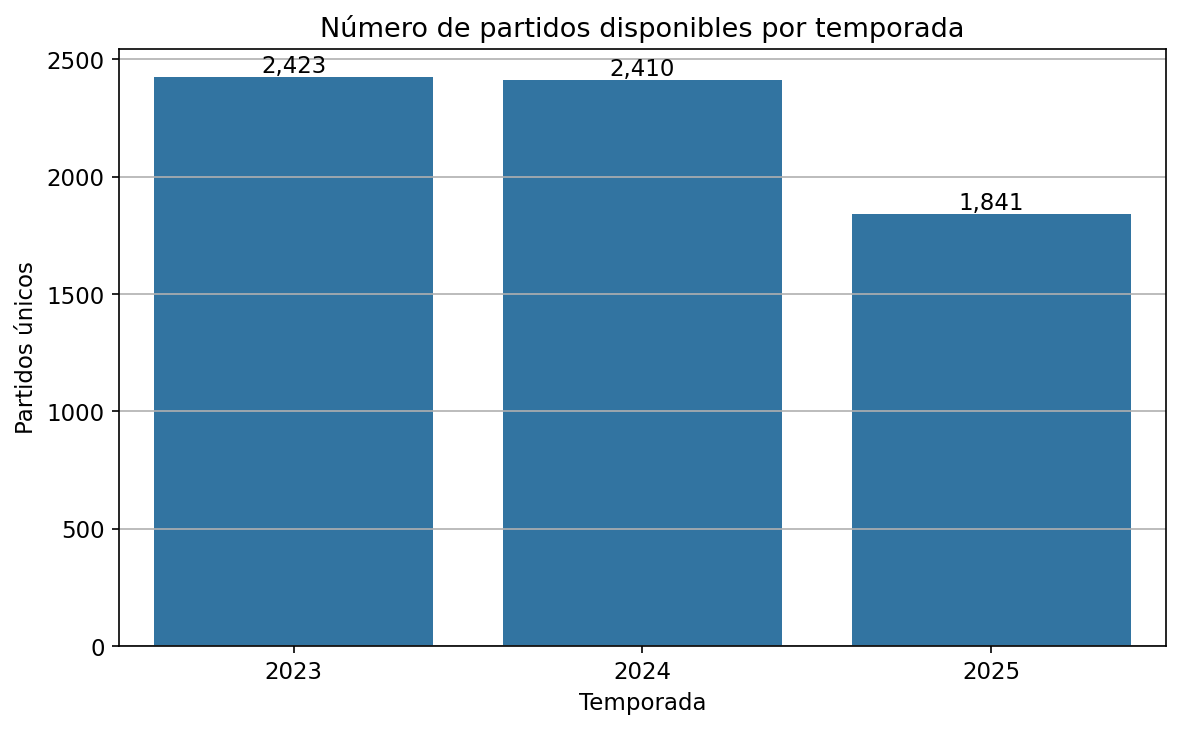

In [360]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=season_summary,
    x="season",
    y="partidos_unicos"
)

plt.title("Número de partidos disponibles por temporada")
plt.xlabel("Temporada")
plt.ylabel("Partidos únicos")

for index, value in enumerate(season_summary["partidos_unicos"]):
    plt.text(
        index,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

save_fig("figura_4_1_partidos_por_temporada")

### <font color='00FFFF'> 1.3 Cobertura por fuente


In [361]:
source_columns = {
    "MLB Stats API": "win_pct_diff",
    "Baseball Savant": "xwoba_diff",
    "Mercado de apuestas": "home_close_prob_mean"
}

source_coverage = []

for source, column in source_columns.items():

    available = df_raw[column].notna().sum()
    missing = df_raw[column].isna().sum()
    coverage_pct = df_raw[column].notna().mean() * 100

    source_coverage.append({
        "Fuente": source,
        "Variable de referencia": column,
        "Registros disponibles": available,
        "Registros faltantes": missing,
        "Cobertura (%)": coverage_pct
    })

source_coverage_df = pd.DataFrame(source_coverage)

display(
    source_coverage_df.round({
        "Cobertura (%)": 2
    })
)

,Fuente,Variable de referencia,Registros disponibles,Registros faltantes,Cobertura (%)
0,MLB Stats API,win_pct_diff,6773,0,100.00
1,Baseball Savant,xwoba_diff,6686,87,98.72
2,Mercado de apuestas,home_close_prob_mean,6773,0,100.00


In [362]:
source_coverage_df.to_csv(
    output_path / "tabla_4_3_cobertura_por_fuente.csv",
    index=False,
    encoding="utf-8-sig"
)

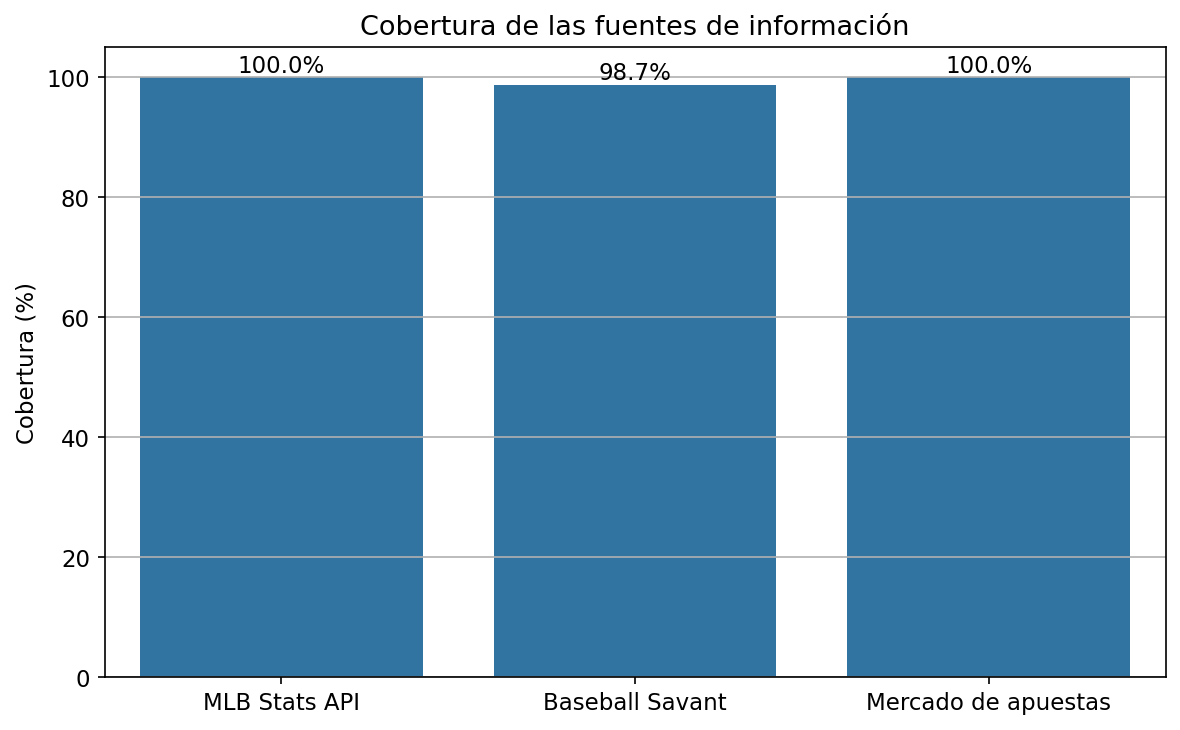

In [363]:
# ============================================================
# FIGURA: COBERTURA POR FUENTE
# ============================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=source_coverage_df,
    x="Fuente",
    y="Cobertura (%)"
)

plt.title("Cobertura de las fuentes de información")
plt.xlabel("")
plt.ylabel("Cobertura (%)")
plt.ylim(0, 105)

for index, value in enumerate(source_coverage_df["Cobertura (%)"]):
    plt.text(
        index,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

save_fig("figura_4_2_cobertura_por_fuente")

In [364]:
# ============================================================
# COBERTURA DEL MERCADO POR TEMPORADA
# ============================================================

odds_coverage_season = (
    df_raw
    .assign(
        has_odds=df_raw["home_close_prob_mean"].notna()
    )
    .groupby("season")
    .agg(
        registros=("game_pk", "size"),
        registros_con_odds=("has_odds", "sum"),
        cobertura_odds=("has_odds", "mean")
    )
    .reset_index()
)

odds_coverage_season["cobertura_odds_pct"] = (
    odds_coverage_season["cobertura_odds"] * 100
)

display(
    odds_coverage_season[
        [
            "season",
            "registros",
            "registros_con_odds",
            "cobertura_odds_pct"
        ]
    ].round(2)
)

,season,registros,registros_con_odds,cobertura_odds_pct
0,2023,2462,2462,100.0
1,2024,2444,2444,100.0
2,2025,1867,1867,100.0


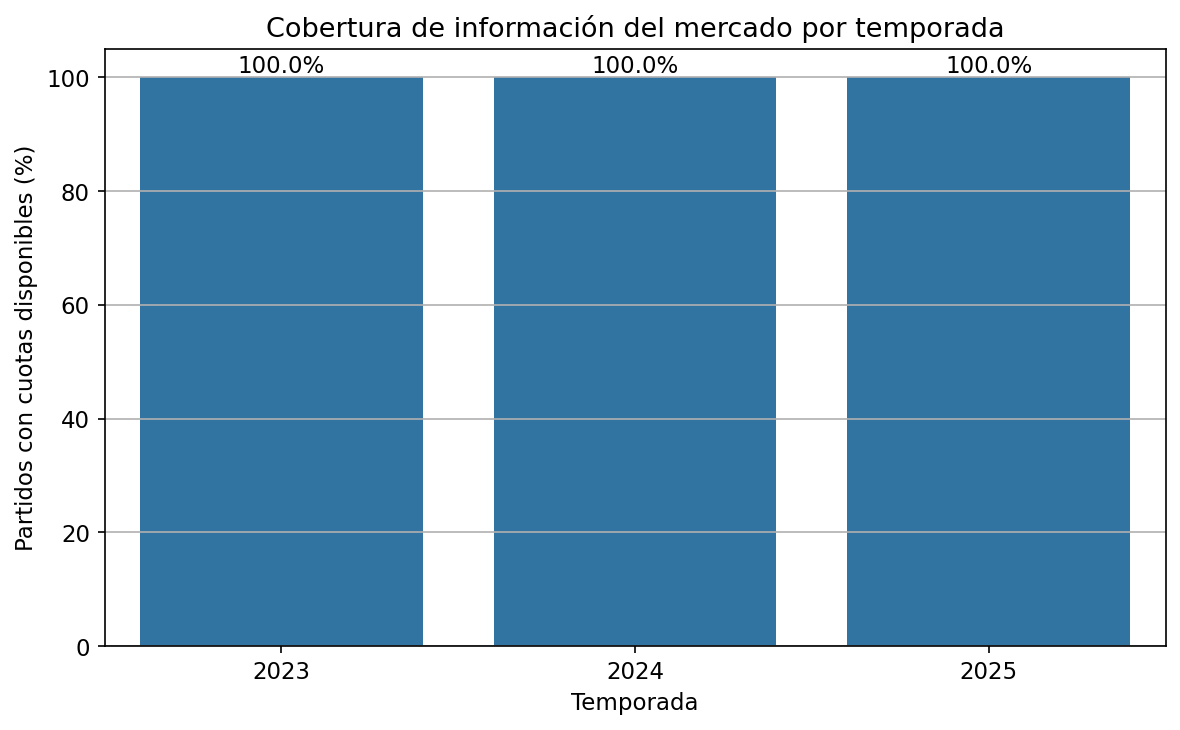

In [365]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=odds_coverage_season,
    x="season",
    y="cobertura_odds_pct"
)

plt.title("Cobertura de información del mercado por temporada")
plt.xlabel("Temporada")
plt.ylabel("Partidos con cuotas disponibles (%)")
plt.ylim(0, 105)

for index, value in enumerate(
    odds_coverage_season["cobertura_odds_pct"]
):
    plt.text(
        index,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

save_fig("figura_4_3_cobertura_odds_por_temporada")

### <font color='00FFFF'>  1.4 Calidad del dataset


In [366]:
# ============================================================
# 1.4 CALIDAD DEL DATASET
# ============================================================

missing_summary = (
    df_raw
    .isna()
    .sum()
    .rename("Valores faltantes")
    .to_frame()
)

missing_summary["Porcentaje faltante"] = (
    missing_summary["Valores faltantes"]
    / len(df_raw)
    * 100
)

missing_summary = (
    missing_summary
    .query("`Valores faltantes` > 0")
    .sort_values(
        "Porcentaje faltante",
        ascending=False
    )
    .reset_index()
    .rename(columns={"index": "Variable"})
)

display(missing_summary.head(20).round(2))

,Variable,Valores faltantes,Porcentaje faltante
0,home_swing_length_last15,1459,21.54
1,home_bat_speed_last15,1459,21.54
2,away_swing_length_last15,1459,21.54
3,away_bat_speed_last15,1459,21.54
4,xwoba_diff,87,1.28
5,xba_diff,87,1.28
6,launch_speed_diff,87,1.28
7,iso_diff,87,1.28
8,away_xwoba_last15,85,1.25
9,away_xba_last15,85,1.25


In [367]:
missing_summary.to_csv(
    output_path / "tabla_4_4_valores_faltantes.csv",
    index=False,
    encoding="utf-8-sig"
)

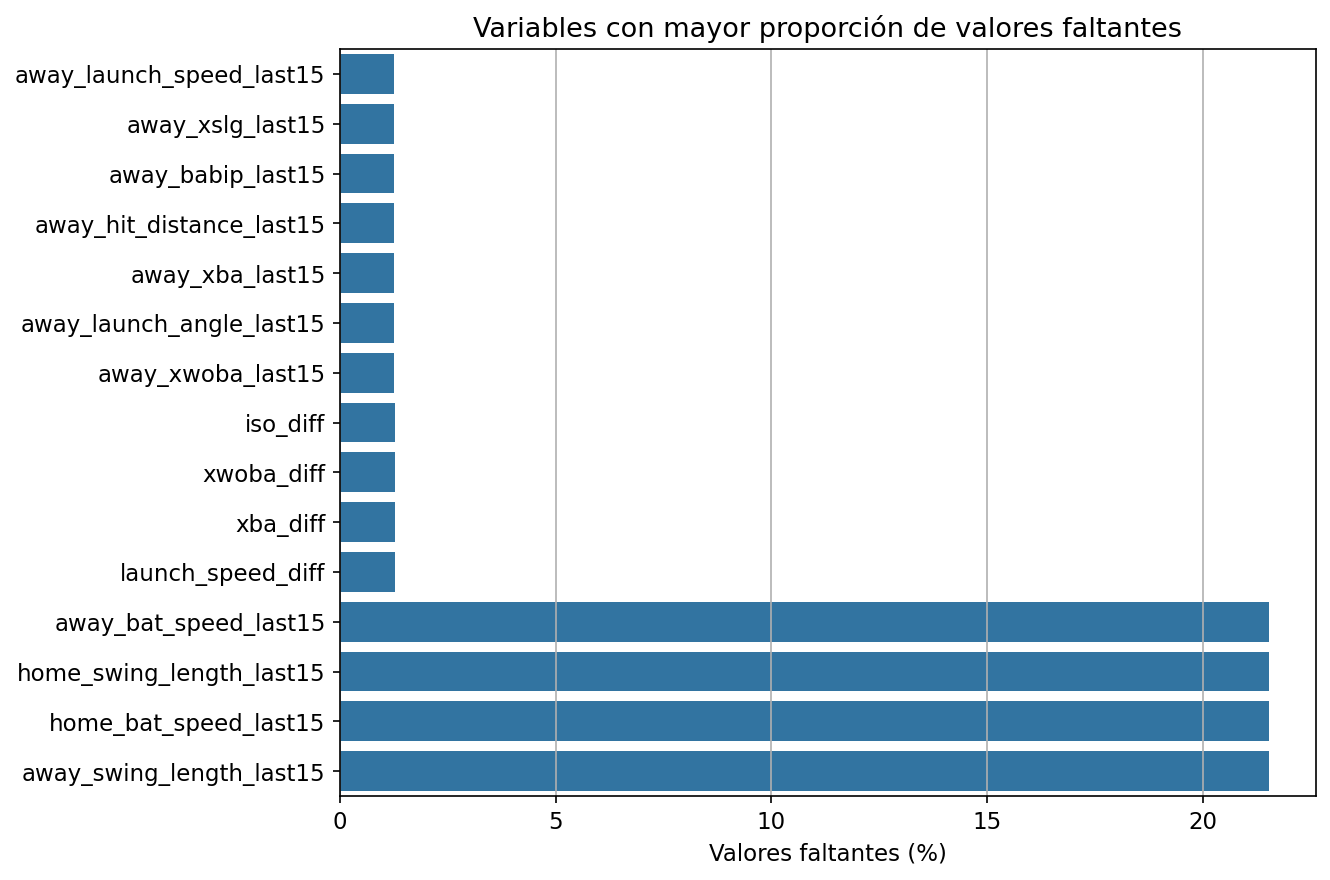

In [368]:
# ============================================================
# FIGURA: VARIABLES CON MAYOR PORCENTAJE DE NULOS
# ============================================================

top_missing = missing_summary.head(15).sort_values(
    "Porcentaje faltante"
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=top_missing,
    x="Porcentaje faltante",
    y="Variable"
)

plt.title("Variables con mayor proporción de valores faltantes")
plt.xlabel("Valores faltantes (%)")
plt.ylabel("")

save_fig("figura_4_4_variables_con_nulos")

In [369]:
# ============================================================
# 1.5 DATASET COMPLETO PARA LOS EXPERIMENTOS
# ============================================================

df_complete = df_raw.dropna().copy()

print("Dataset original:", df_raw.shape)
print("Dataset completo:", df_complete.shape)

print(
    "Registros eliminados:",
    len(df_raw) - len(df_complete)
)

print(
    "Porcentaje conservado:",
    round(len(df_complete) / len(df_raw) * 100, 2),
    "%"
)

print(
    "Partidos únicos conservados:",
    df_complete["game_pk"].nunique()
)

Dataset original: (6773, 103)
Dataset completo: (5312, 103)
Registros eliminados: 1461
Porcentaje conservado: 78.43 %
Partidos únicos conservados: 5237


In [370]:
dataset_comparison = pd.DataFrame({
    "Conjunto": [
        "Dataset integrado original",
        "Dataset completo para modelado"
    ],
    "Registros": [
        len(df_raw),
        len(df_complete)
    ],
    "Variables": [
        df_raw.shape[1],
        df_complete.shape[1]
    ],
    "Partidos únicos": [
        df_raw["game_pk"].nunique(),
        df_complete["game_pk"].nunique()
    ]
})

dataset_comparison["Registros conservados (%)"] = [
    100,
    len(df_complete) / len(df_raw) * 100
]

display(dataset_comparison.round(2))

,Conjunto,Registros,Variables,Partidos únicos,Registros conservados (%)
0,Dataset integrado original,6773,103,6674,100.00
1,Dataset completo para modelado,5312,103,5237,78.43


In [371]:
dataset_comparison.to_csv(
    output_path / "tabla_4_5_dataset_original_vs_completo.csv",
    index=False,
    encoding="utf-8-sig"
)

In [372]:
# Dataset utilizado en las siguientes secciones
df = df_complete.copy()

print("Dataset activo:", df.shape)

Dataset activo: (5312, 103)


# <font color='00FF00'> 2. INGENIERÍA Y SELECCIÓN DE VARIABLES


### <font color='00FFFF'> 2.1 Variable objetivo


In [373]:
# ============================================================
# 2.1 VARIABLE OBJETIVO
# ============================================================

target_summary = (
    df["home_win"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("home_win")
    .reset_index(name="Registros")
)

target_summary["Porcentaje"] = (
    target_summary["Registros"]
    / target_summary["Registros"].sum()
    * 100
)

target_summary["Clase"] = target_summary["home_win"].map({
    0: "Victoria visitante",
    1: "Victoria local"
})

target_summary = target_summary[
    ["home_win", "Clase", "Registros", "Porcentaje"]
]

display(target_summary.round(2))

,home_win,Clase,Registros,Porcentaje
0,0,Victoria visitante,2524,47.52
1,1,Victoria local,2788,52.48


In [374]:
print("Total de registros:", len(df))
print("Valores nulos en home_win:", df["home_win"].isna().sum())
print("Valores únicos:", sorted(df["home_win"].dropna().unique()))
print("Proporción de victorias locales:", round(df["home_win"].mean(), 4))

Total de registros: 5312
Valores nulos en home_win: 0
Valores únicos: [np.int64(0), np.int64(1)]
Proporción de victorias locales: 0.5248


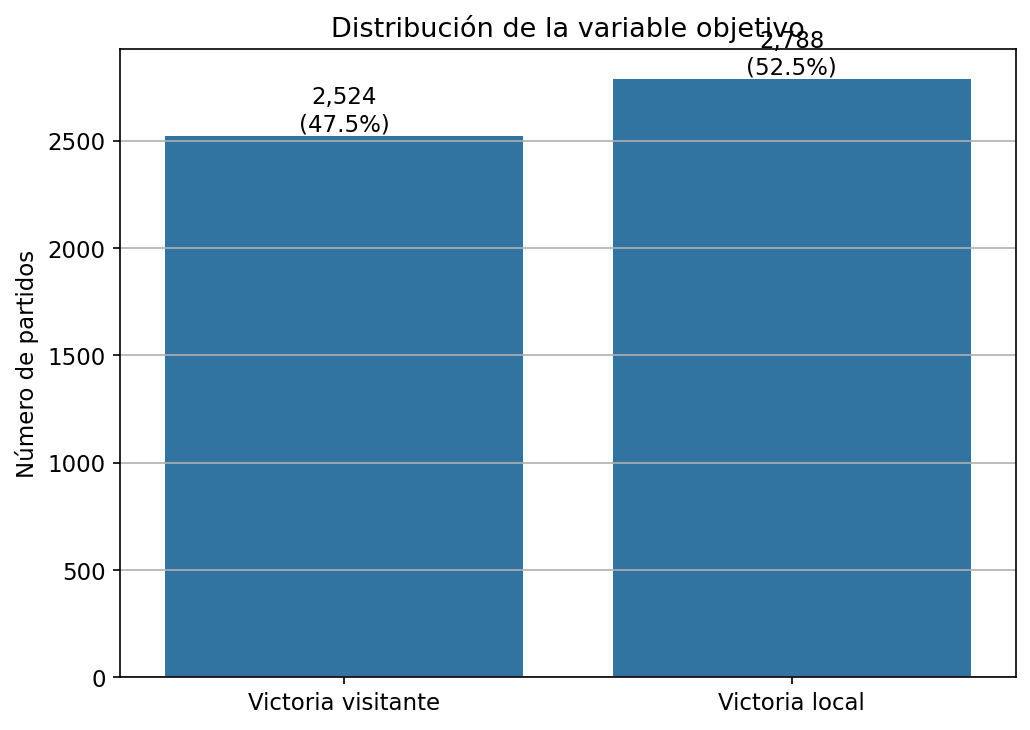

In [375]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=target_summary,
    x="Clase",
    y="Registros"
)

plt.title("Distribución de la variable objetivo")
plt.xlabel("")
plt.ylabel("Número de partidos")

for i, row in target_summary.reset_index(drop=True).iterrows():
    ax.text(
        i,
        row["Registros"],
        f"{int(row['Registros']):,}\n({row['Porcentaje']:.1f}%)",
        ha="center",
        va="bottom"
    )

save_fig("figura_4_4_distribucion_variable_objetivo")

In [376]:
target_summary.to_csv(
    output_path / "tabla_4_6_distribucion_variable_objetivo.csv",
    index=False,
    encoding="utf-8-sig"
)

### <font color='00FFFF'> 2.2 ANÁLISIS INICIAL DE VARIABLES


In [377]:
# ============================================================
# 2.2 ANÁLISIS INICIAL DE VARIABLES
# ============================================================

print("="*60)
print("INFORMACIÓN GENERAL")
print("="*60)

print("Variables totales:", df.shape[1])

numeric_cols = df.select_dtypes(include=np.number).columns

categorical_cols = df.select_dtypes(
    include=["object","category","bool"]
).columns

datetime_cols = df.select_dtypes(
    include=["datetime"]
).columns

print("Variables numéricas:", len(numeric_cols))
print("Variables categóricas:", len(categorical_cols))
print("Variables fecha:", len(datetime_cols))

INFORMACIÓN GENERAL
Variables totales: 103
Variables numéricas: 75
Variables categóricas: 21
Variables fecha: 3


In [378]:
variable_summary = pd.DataFrame({
    "Tipo": [
        "Numéricas",
        "Categóricas",
        "Fecha"
    ],
    "Cantidad": [
        len(numeric_cols),
        len(categorical_cols),
        len(datetime_cols)
    ]
})

display(variable_summary)

,Tipo,Cantidad
0,Numéricas,75
1,Categóricas,21
2,Fecha,3


In [379]:
stats_cols = [
    c for c in df.columns
    if (
        "wins" in c
        or "losses" in c
        or "pct" in c
        or "dayNight" in c
        or "series" in c
        or "game" in c
    )
]

savant_cols = [
    c for c in df.columns
    if any(
        x in c
        for x in [
            "xba",
            "xwoba",
            "xslg",
            "launch",
            "iso",
            "babip",
            "woba",
            "hit_distance",
            "bat_speed",
            "swing_length"
        ]
    )
]

market_cols = [
    c for c in df.columns
    if any(
        x in c
        for x in [
            "prob",
            "market",
            "sportsbook",
            "line",
            "odds"
        ]
    )
]

summary_sources = pd.DataFrame({
    "Fuente":[
        "MLB Stats API",
        "Baseball Savant",
        "Mercado"
    ],
    "Variables":[
        len(stats_cols),
        len(savant_cols),
        len(market_cols)
    ]
})

display(summary_sources)

,Fuente,Variables
0,MLB Stats API,24
1,Baseball Savant,26
2,Mercado,32


In [380]:
missing_count = (
    df
    .isna()
    .sum()
)

print(
    "Variables con al menos un nulo:",
    (missing_count>0).sum()
)

print(
    "Variables completas:",
    (missing_count==0).sum()
)

Variables con al menos un nulo: 0
Variables completas: 103


### <font color='00FFFF'> 2.2 Depuración inicial de variables


In [381]:
# ============================================================
# 2.3 DEPURACIÓN INICIAL DE VARIABLES
# ============================================================

# Variables eliminadas por criterio de negocio
cols_drop = [

    # No aportan señal y presentan alta proporción de nulos
    'home_bat_speed_last15',
    'away_bat_speed_last15',
    'home_swing_length_last15',
    'away_swing_length_last15',

    # Información redundante del récord
    'home_wins_before',
    'away_wins_before',
    'home_losses_before',
    'away_losses_before',
    'home_games_played',
    'away_games_played',
    'home_pct_before',
    'away_pct_before',

    # Variables Savant originales
    'home_xba_last15',
    'away_xba_last15',

    'home_xwoba_last15',
    'away_xwoba_last15',

    'home_launch_speed_last15',
    'away_launch_speed_last15',

    'home_iso_last15',
    'away_iso_last15',

    # Variable constante
    'scheduledInnings'
]

# Variables eliminadas posteriormente
cols_drop_vif = [

    # Identificadores
    'game_pk',

    # Variables de calendario
    'gameNumber',
    'gamesInSeries',

    # Métricas Statcast Home
    'home_launch_angle_last15',
    'home_hit_distance_last15',
    'home_xslg_last15',
    'home_woba_last15',
    'home_babip_last15',

    # Métricas Statcast Away
    'away_launch_angle_last15',
    'away_hit_distance_last15',
    'away_xslg_last15',
    'away_woba_last15',
    'away_babip_last15',
]

In [382]:
print("="*60)
print("DEPURACIÓN INICIAL")
print("="*60)

print("Variables iniciales :", df.shape[1])

print("Eliminadas (criterio de negocio):", len(cols_drop))

print("Eliminadas (reducción adicional):", len(cols_drop_vif))

print("Total eliminadas:",
      len(cols_drop)+len(cols_drop_vif))

DEPURACIÓN INICIAL
Variables iniciales : 103
Eliminadas (criterio de negocio): 21
Eliminadas (reducción adicional): 13
Total eliminadas: 34


In [383]:
depuration_summary = pd.DataFrame({

    "Etapa":[

        "Variables iniciales",

        "Eliminación por criterio de negocio",

        "Eliminación por redundancia e identificadores",

        "Variables restantes"

    ],

    "Cantidad":[

        df.shape[1],

        len(cols_drop),

        len(cols_drop_vif),

        df.shape[1]-len(cols_drop)-len(cols_drop_vif)

    ]

})

display(depuration_summary)

,Etapa,Cantidad
0,Variables iniciales,103
1,Eliminación por criterio de negocio,21
2,Eliminación por redundancia e identificadores,13
3,Variables restantes,69


In [384]:
depuration_detail = pd.DataFrame({

    "Grupo":[

        "Alta proporción de nulos",

        "Variables redundantes del récord",

        "Variables Statcast originales",

        "Variables constantes",

        "Identificadores",

        "Variables de calendario",

        "Variables Statcast redundantes"

    ],

    "Variables eliminadas":[

        4,

        8,

        8,

        1,

        1,

        2,

        10

    ]

})

display(depuration_detail)

,Grupo,Variables eliminadas
0,Alta proporción de nulos,4
1,Variables redundantes del récord,8
2,Variables Statcast originales,8
3,Variables constantes,1
4,Identificadores,1
5,Variables de calendario,2
6,Variables Statcast redundantes,10


In [385]:
funnel = pd.DataFrame({

    "Etapa":[

        "Dataset inicial",

        "Después de depuración",

    ],

    "Variables":[

        df.shape[1],

        df.shape[1]-len(cols_drop)-len(cols_drop_vif)

    ]

})

display(funnel)

,Etapa,Variables
0,Dataset inicial,103
1,Después de depuración,69


### <font color='00FFFF'> 2.3 SELECCIÓN ESTADÍSTICA DE VARIABLES





####CORRELACIÓN CON LA VARIABLE OBJETIVO


In [386]:
# Trabajamos sobre una copia para no modificar el dataframe original
df_selection = df.copy()

# Aplicar las dos etapas de depuración ya documentadas
cols_to_remove = [
    col
    for col in (cols_drop + cols_drop_vif)
    if col in df_selection.columns
]

df_selection = df_selection.drop(
    columns=cols_to_remove
)

print("Variables antes de la depuración:", df.shape[1])
print("Variables eliminadas:", len(cols_to_remove))
print("Variables después de la depuración:", df_selection.shape[1])

Variables antes de la depuración: 103
Variables eliminadas: 34
Variables después de la depuración: 69


In [387]:
# Columnas que no deben considerarse variables predictoras
exclude_numeric = [
    "home_win",       # variable objetivo
    "season"          # información temporal/identificadora
]

numeric_candidates = [
    col
    for col in df_selection.select_dtypes(include=np.number).columns
    if col not in exclude_numeric
]

print("Variables numéricas candidatas:", len(numeric_candidates))
print(numeric_candidates)

Variables numéricas candidatas: 40
['seriesGameNumber', 'win_pct_diff', 'wins_diff', 'schedule_game_number', 'xwoba_diff', 'xba_diff', 'launch_speed_diff', 'iso_diff', 'num_sportsbooks', 'home_open_prob_mean', 'home_open_prob_median', 'home_open_prob_std', 'home_open_prob_min', 'home_open_prob_max', 'away_open_prob_mean', 'away_open_prob_median', 'away_open_prob_std', 'away_open_prob_min', 'away_open_prob_max', 'home_close_prob_mean', 'home_close_prob_median', 'home_close_prob_std', 'home_close_prob_min', 'home_close_prob_max', 'away_close_prob_mean', 'away_close_prob_median', 'away_close_prob_std', 'away_close_prob_min', 'away_close_prob_max', 'opening_overround_mean', 'closing_overround_mean', 'open_prob_diff', 'close_prob_diff', 'home_open_favorite', 'home_close_favorite', 'open_market_strength', 'close_market_strength', 'home_line_movement', 'away_line_movement', 'season_odds']


#### Calcular correlación con home_win

In [388]:
target_correlations = (
    df_selection[numeric_candidates + ["home_win"]]
    .corr(numeric_only=True)["home_win"]
    .drop("home_win")
    .rename("Correlación")
    .to_frame()
)

target_correlations["Correlación absoluta"] = (
    target_correlations["Correlación"].abs()
)

target_correlations = (
    target_correlations
    .sort_values(
        "Correlación absoluta",
        ascending=False
    )
    .reset_index()
    .rename(columns={"index": "Variable"})
)

display(target_correlations.round(4))

,Variable,Correlación,Correlación absoluta
0,away_close_prob_max,-0.1806,0.1806
1,home_close_prob_min,0.1806,0.1806
2,home_close_prob_mean,0.1779,0.1779
3,close_prob_diff,0.1779,0.1779
4,away_close_prob_mean,-0.1779,0.1779
5,home_close_prob_median,0.1750,0.1750
6,away_close_prob_median,-0.1750,0.1750
7,away_close_prob_min,-0.1718,0.1718
8,home_close_prob_max,0.1718,0.1718
9,away_open_prob_max,-0.1673,0.1673


In [389]:
target_correlations.to_csv(
    output_path / "tabla_4_11_correlacion_variables_target.csv",
    index=False,
    encoding="utf-8-sig"
)

In [390]:
correlation_threshold = 0.05

relevant_target_correlations = (
    target_correlations[
        target_correlations["Correlación absoluta"]
        >= correlation_threshold
    ]
    .copy()
)

print(
    "Variables con correlación absoluta >=",
    correlation_threshold,
    ":",
    len(relevant_target_correlations)
)

display(relevant_target_correlations.round(4))

Variables con correlación absoluta >= 0.05 : 29


,Variable,Correlación,Correlación absoluta
0,away_close_prob_max,-0.1806,0.1806
1,home_close_prob_min,0.1806,0.1806
2,home_close_prob_mean,0.1779,0.1779
3,close_prob_diff,0.1779,0.1779
4,away_close_prob_mean,-0.1779,0.1779
5,home_close_prob_median,0.1750,0.1750
6,away_close_prob_median,-0.1750,0.1750
7,away_close_prob_min,-0.1718,0.1718
8,home_close_prob_max,0.1718,0.1718
9,away_open_prob_max,-0.1673,0.1673


In [391]:
relevant_target_correlations.to_csv(
    output_path / "tabla_4_12_correlaciones_relevantes_target.csv",
    index=False,
    encoding="utf-8-sig"
)

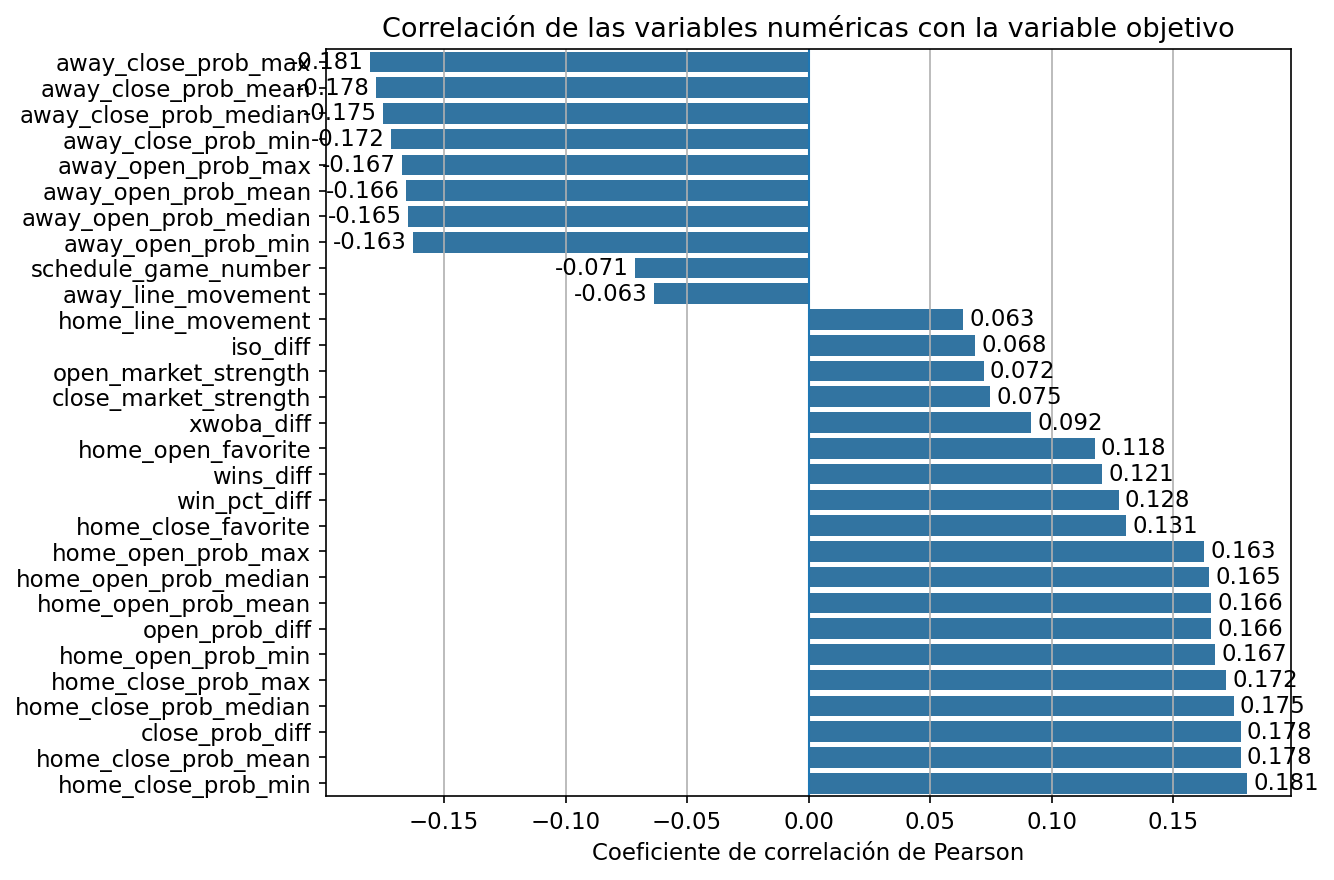

In [392]:
plot_target_corr = (
    relevant_target_correlations
    .sort_values("Correlación")
    .copy()
)

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=plot_target_corr,
    x="Correlación",
    y="Variable"
)

plt.axvline(
    x=0,
    linewidth=1
)

plt.title("Correlación de las variables numéricas con la variable objetivo")
plt.xlabel("Coeficiente de correlación de Pearson")
plt.ylabel("")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

save_fig("figura_4_6_correlacion_variables_target")

#### REDUNDANCIA ENTRE VARIABLES

In [393]:
corr_features = (
    relevant_target_correlations["Variable"]
    .tolist()
)

print("Variables analizadas:", len(corr_features))
print(corr_features)

Variables analizadas: 29
['away_close_prob_max', 'home_close_prob_min', 'home_close_prob_mean', 'close_prob_diff', 'away_close_prob_mean', 'home_close_prob_median', 'away_close_prob_median', 'away_close_prob_min', 'home_close_prob_max', 'away_open_prob_max', 'home_open_prob_min', 'away_open_prob_mean', 'open_prob_diff', 'home_open_prob_mean', 'away_open_prob_median', 'home_open_prob_median', 'away_open_prob_min', 'home_open_prob_max', 'home_close_favorite', 'win_pct_diff', 'wins_diff', 'home_open_favorite', 'xwoba_diff', 'close_market_strength', 'open_market_strength', 'schedule_game_number', 'iso_diff', 'home_line_movement', 'away_line_movement']


In [394]:
corr_matrix = (
    df_selection[corr_features]
    .corr(numeric_only=True)
)

display(
    corr_matrix.round(3)
)

,away_close_prob_max,home_close_prob_min,home_close_prob_mean,close_prob_diff,away_close_prob_mean,home_close_prob_median,away_close_prob_median,away_close_prob_min,home_close_prob_max,away_open_prob_max,...,win_pct_diff,wins_diff,home_open_favorite,xwoba_diff,close_market_strength,open_market_strength,schedule_game_number,iso_diff,home_line_movement,away_line_movement
away_close_prob_max,1.000,-1.000,-0.966,-0.966,0.966,-0.951,0.951,0.905,-0.905,0.898,...,-0.631,-0.642,-0.714,-0.427,-0.374,-0.337,0.045,-0.302,-0.332,0.332
home_close_prob_min,-1.000,1.000,0.966,0.966,-0.966,0.951,-0.951,-0.905,0.905,-0.898,...,0.631,0.642,0.714,0.427,0.374,0.337,-0.045,0.302,0.332,-0.332
home_close_prob_mean,-0.966,0.966,1.000,1.000,-1.000,0.997,-0.997,-0.975,0.975,-0.944,...,0.664,0.676,0.752,0.445,0.394,0.352,-0.037,0.308,0.300,-0.300
close_prob_diff,-0.966,0.966,1.000,1.000,-1.000,0.997,-0.997,-0.975,0.975,-0.944,...,0.664,0.676,0.752,0.445,0.394,0.352,-0.037,0.308,0.300,-0.300
away_close_prob_mean,0.966,-0.966,-1.000,-1.000,1.000,-0.997,0.997,0.975,-0.975,0.944,...,-0.664,-0.676,-0.752,-0.445,-0.394,-0.352,0.037,-0.308,-0.300,0.300
home_close_prob_median,-0.951,0.951,0.997,0.997,-0.997,1.000,-1.000,-0.968,0.968,-0.946,...,0.665,0.677,0.754,0.448,0.392,0.353,-0.037,0.309,0.282,-0.282
away_close_prob_median,0.951,-0.951,-0.997,-0.997,0.997,-1.000,1.000,0.968,-0.968,0.946,...,-0.665,-0.677,-0.754,-0.448,-0.392,-0.353,0.037,-0.309,-0.282,0.282
away_close_prob_min,0.905,-0.905,-0.975,-0.975,0.975,-0.968,0.968,1.000,-1.000,0.919,...,-0.650,-0.660,-0.733,-0.428,-0.388,-0.343,0.028,-0.293,-0.293,0.293
home_close_prob_max,-0.905,0.905,0.975,0.975,-0.975,0.968,-0.968,-1.000,1.000,-0.919,...,0.650,0.660,0.733,0.428,0.388,0.343,-0.028,0.293,0.293,-0.293
away_open_prob_max,0.898,-0.898,-0.944,-0.944,0.944,-0.946,0.946,0.919,-0.919,1.000,...,-0.677,-0.690,-0.788,-0.444,-0.378,-0.376,0.030,-0.299,0.012,-0.012


In [395]:
corr_matrix.round(4).to_csv(
    output_path / "tabla_4_13_matriz_correlacion.csv",
    encoding="utf-8-sig"
)

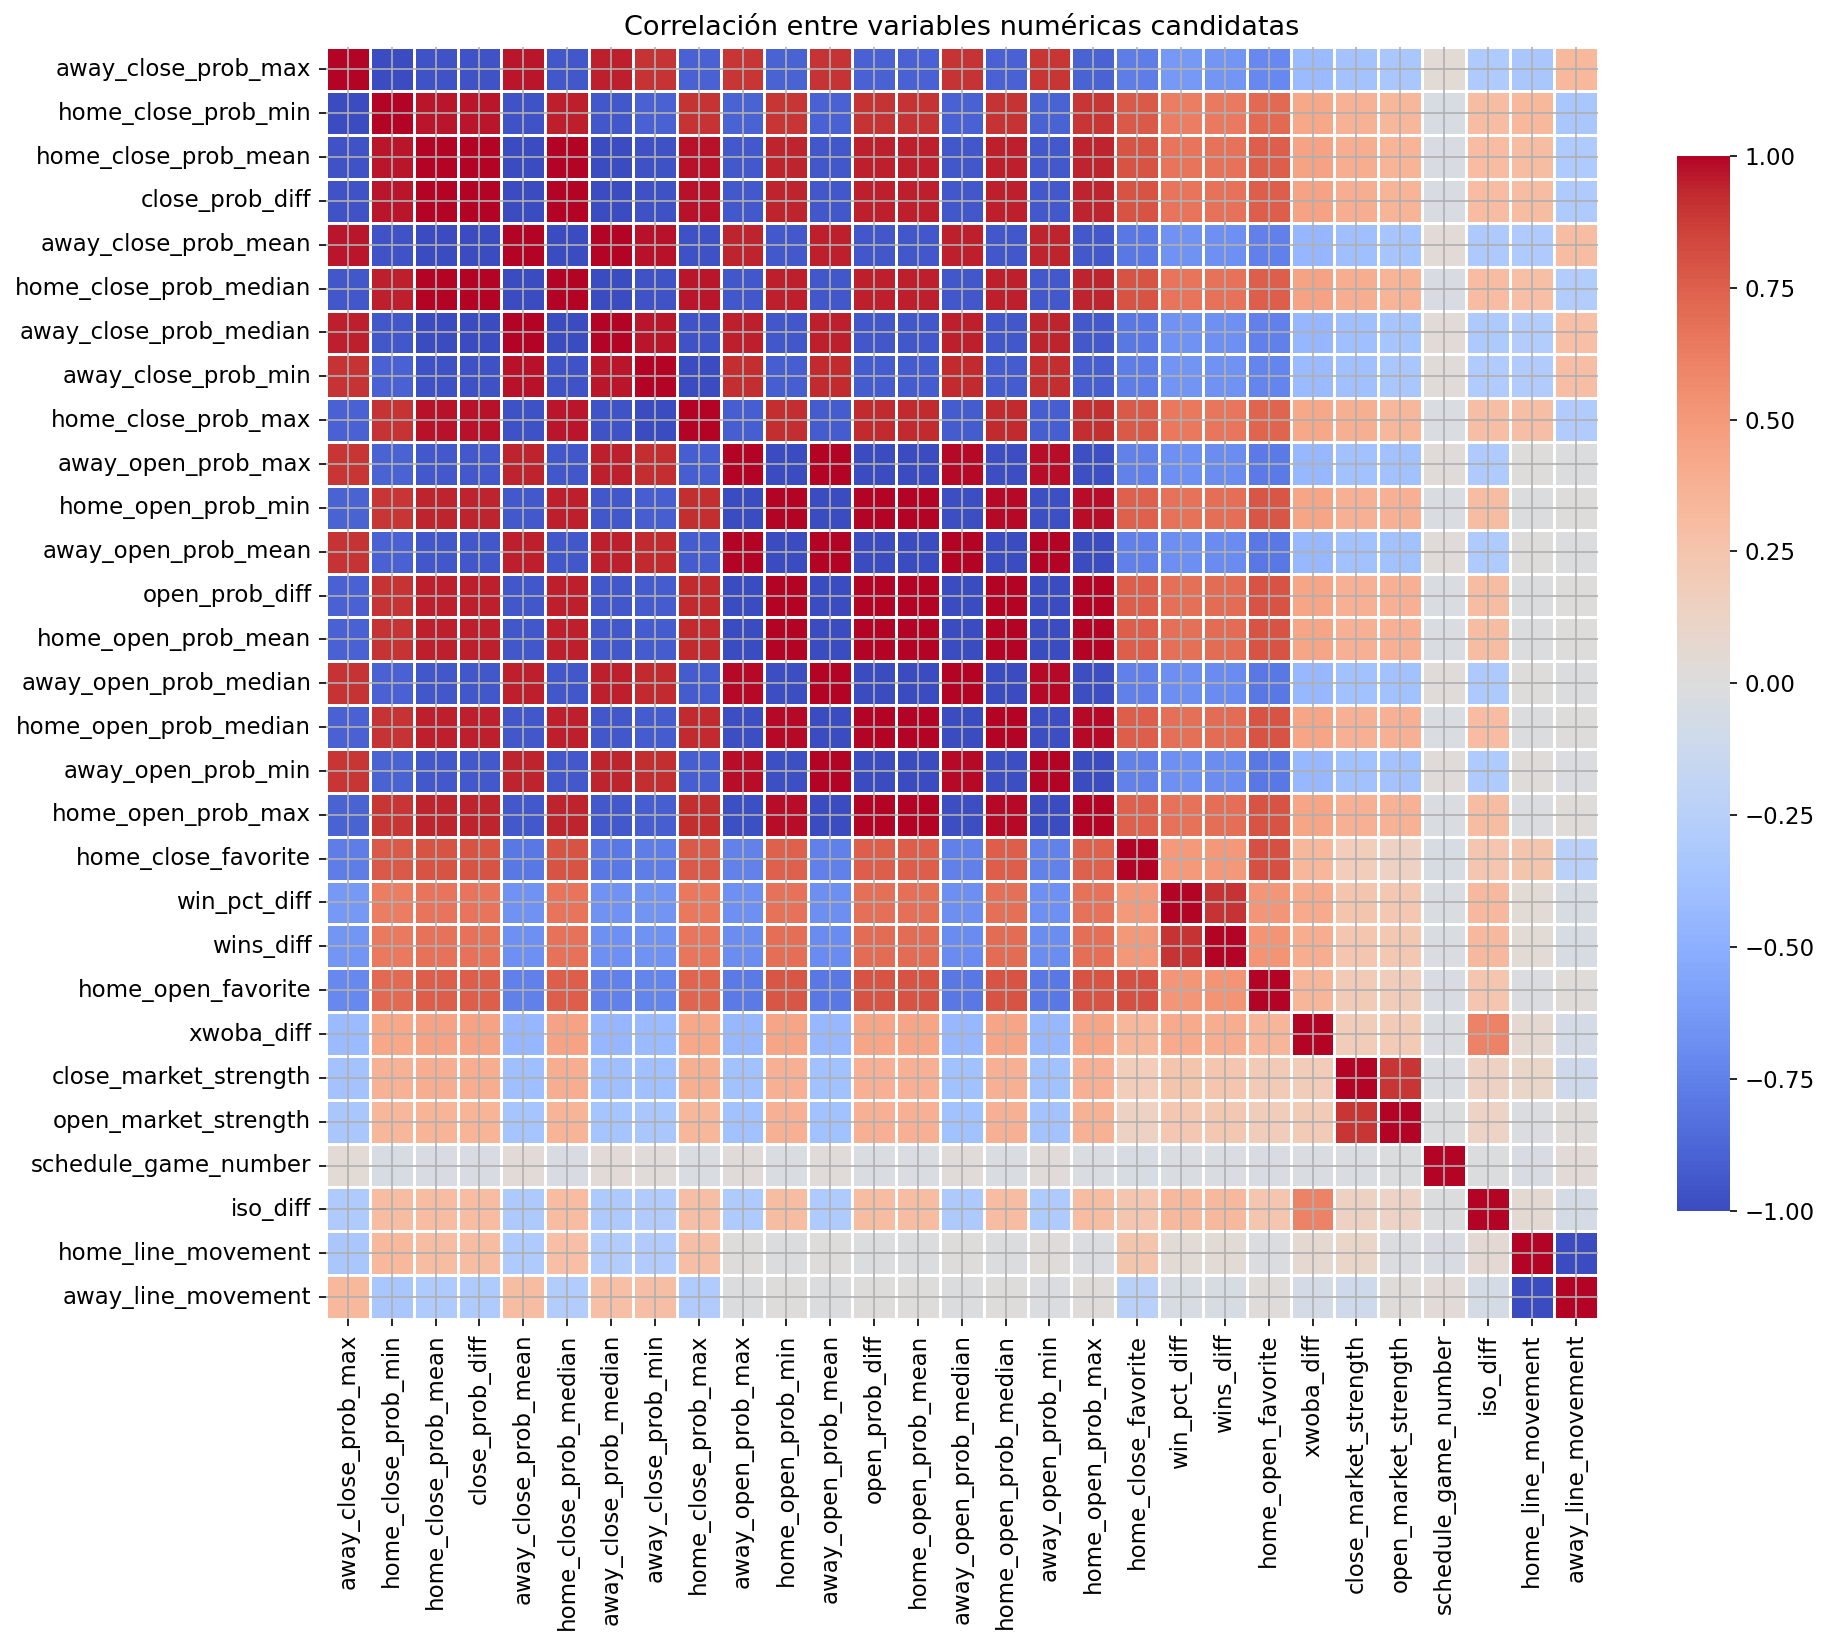

In [396]:
plt.figure(figsize=(13,11))

sns.heatmap(

    corr_matrix,

    cmap="coolwarm",

    center=0,

    square=True,

    linewidths=.5,

    cbar_kws={
        "shrink":0.8
    }

)

plt.title(
    "Correlación entre variables numéricas candidatas"
)

save_fig(
    "figura_4_7_heatmap_correlaciones"
)

In [397]:
# ============================================================
# PARES ALTAMENTE CORRELACIONADOS
# ============================================================

corr_upper = (
    corr_matrix.abs()
    .where(
        np.triu(
            np.ones(corr_matrix.shape),
            k=1
        ).astype(bool)
    )
)

high_corr_pairs = []

for col in corr_upper.columns:

    for row in corr_upper.index:

        value = corr_upper.loc[row,col]

        if pd.notna(value):

            if value >= 0.90:

                high_corr_pairs.append({

                    "Variable 1":row,

                    "Variable 2":col,

                    "Correlación":value

                })

high_corr_pairs = (
    pd.DataFrame(high_corr_pairs)
    .sort_values(
        "Correlación",
        ascending=False
    )
)

display(
    high_corr_pairs.round(3)
)

,Variable 1,Variable 2,Correlación
73,away_open_prob_mean,open_prob_diff,1.000
9,close_prob_diff,away_close_prob_mean,1.000
35,away_close_prob_min,home_close_prob_max,1.000
85,away_open_prob_mean,home_open_prob_mean,1.000
146,home_line_movement,away_line_movement,1.000
...,...,...,...
145,win_pct_diff,wins_diff,0.903
102,home_close_prob_min,home_open_prob_median,0.903
101,away_close_prob_max,home_open_prob_median,0.903
87,away_close_prob_max,away_open_prob_median,0.903


In [398]:
high_corr_pairs.to_csv(

    output_path /
    "tabla_4_14_pares_altamente_correlacionados.csv",

    index=False,

    encoding="utf-8-sig"

)

In [399]:
len(high_corr_pairs)

147

In [400]:
display(high_corr_pairs.head(30))

,Variable 1,Variable 2,Correlación
73,away_open_prob_mean,open_prob_diff,1.000000
9,close_prob_diff,away_close_prob_mean,1.000000
35,away_close_prob_min,home_close_prob_max,1.000000
85,away_open_prob_mean,home_open_prob_mean,1.000000
146,home_line_movement,away_line_movement,1.000000
0,away_close_prob_max,home_close_prob_min,1.000000
86,open_prob_diff,home_open_prob_mean,1.000000
20,home_close_prob_median,away_close_prob_median,1.000000
115,away_open_prob_median,home_open_prob_median,1.000000
8,home_close_prob_mean,away_close_prob_mean,1.000000


### <font color='00FFFF'> 2.4 Variables Categoricas


In [401]:
sorted(df.select_dtypes(include=["object","category"]).columns)

['abstract_game_state',
 'away_team',
 'away_team_join',
 'away_team_name',
 'dayNight',
 'double_header',
 'game_status',
 'home_team',
 'home_team_join',
 'home_team_name',
 'merge_key',
 'odds_match_key',
 'odds_match_key_game',
 'schedule_away_team',
 'schedule_home_team',
 'schedule_venue',
 'season',
 'teams.away.team.name',
 'teams.home.team.name',
 'venue.name']

In [402]:
categorical_features = [
    "dayNight",
    "teams.home.team.name",
    "teams.away.team.name",
    "venue.name",
    "double_header"
]

# Conservar únicamente las columnas disponibles
categorical_features = [
    col for col in categorical_features
    if col in df.columns
]

print("Variables categóricas analizadas:")
print(categorical_features)

Variables categóricas analizadas:
['dayNight', 'teams.home.team.name', 'teams.away.team.name', 'venue.name', 'double_header']


In [403]:
cat_summary = []

for col in categorical_features:

    frequencies = (
        df[col]
        .value_counts(
            normalize=True,
            dropna=False
        )
        * 100
    )

    cat_summary.append({
        "Variable": col,
        "Número de categorías": df[col].nunique(dropna=False),
        "Categoría más frecuente": frequencies.index[0],
        "Frecuencia categoría principal (%)": frequencies.iloc[0],
        "Valores faltantes": df[col].isna().sum()
    })

cat_summary = pd.DataFrame(cat_summary)

display(cat_summary.round(2))

,Variable,Número de categorías,Categoría más frecuente,Frecuencia categoría principal (%),Valores faltantes
0,dayNight,2,night,62.35,0
1,teams.home.team.name,31,New York Mets,3.56,0
2,teams.away.team.name,31,Atlanta Braves,3.50,0
3,venue.name,39,Citi Field,3.54,0
4,double_header,3,N,96.16,0


In [404]:
cat_summary.to_csv(
    output_path / "tabla_4_15_resumen_variables_categoricas.csv",
    index=False,
    encoding="utf-8-sig"
)

In [405]:
from scipy.stats import contingency

def cramers_v(x, y):
    """
    Calcula Cramér's V entre dos variables categóricas.
    Devuelve NaN si la tabla no permite calcular la asociación.
    """
    contingency_table = pd.crosstab(x, y)

    if (
        contingency_table.shape[0] < 2
        or contingency_table.shape[1] < 2
    ):
        return np.nan

    return contingency.association(
        contingency_table,
        method="cramer"
    )

In [406]:
cramer_matrix = pd.DataFrame(
    index=categorical_features,
    columns=categorical_features,
    dtype=float
)

for col_1 in categorical_features:
    for col_2 in categorical_features:
        cramer_matrix.loc[col_1, col_2] = cramers_v(
            df[col_1],
            df[col_2]
        )

display(cramer_matrix.round(3))

,dayNight,teams.home.team.name,teams.away.team.name,venue.name,double_header
dayNight,1.000,0.152,0.065,0.158,0.043
teams.home.team.name,0.152,1.000,0.126,1.000,0.187
teams.away.team.name,0.065,0.126,1.000,0.135,0.135
venue.name,0.158,1.000,0.135,1.000,0.191
double_header,0.043,0.187,0.135,0.191,1.000


In [407]:
cramer_matrix.round(4).to_csv(
    output_path / "tabla_4_16_matriz_cramers_v.csv",
    encoding="utf-8-sig"
)

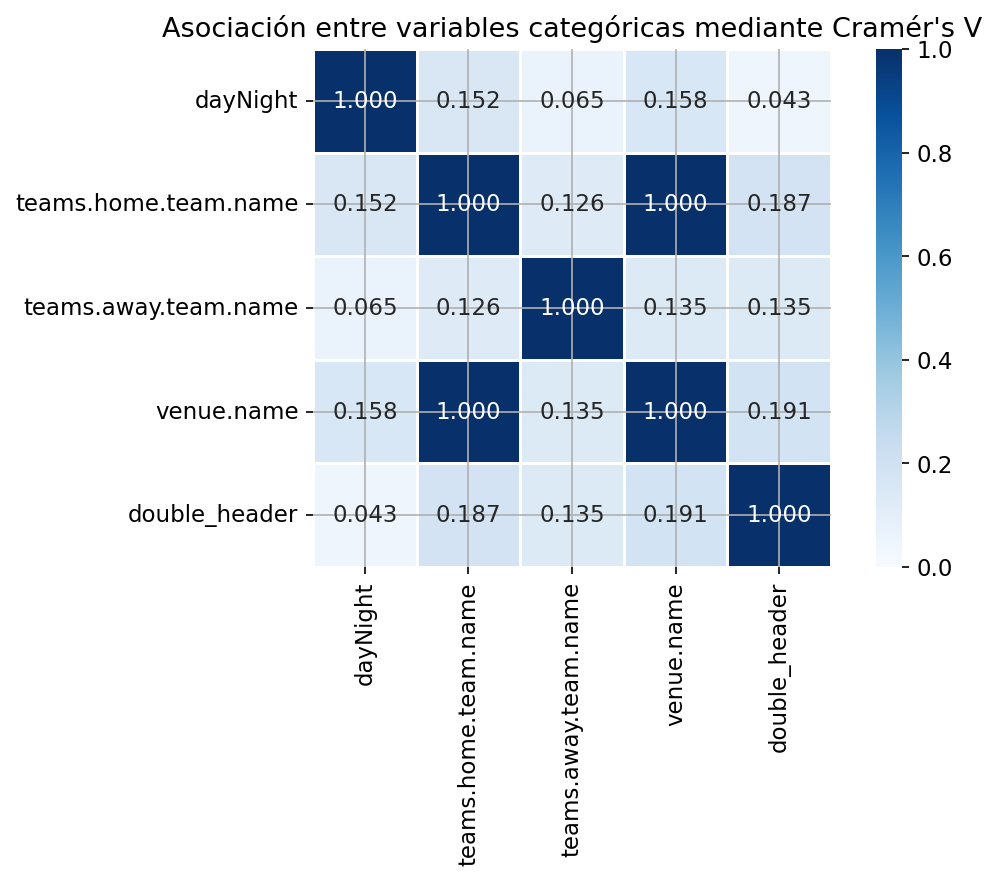

In [408]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    cramer_matrix,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    square=True,
    vmin=0,
    vmax=1,
    linewidths=0.5
)

plt.title("Asociación entre variables categóricas mediante Cramér's V")
plt.xlabel("")
plt.ylabel("")

save_fig("figura_4_8_matriz_cramers_v")

In [409]:
cramer_target = pd.DataFrame({
    "Variable": categorical_features,
    "Cramér's V": [
        cramers_v(df[col], df["home_win"])
        for col in categorical_features
    ]
})

cramer_target = (
    cramer_target
    .sort_values(
        "Cramér's V",
        ascending=False
    )
    .reset_index(drop=True)
)

display(cramer_target.round(4))

,Variable,Cramér's V
0,venue.name,0.1498
1,teams.away.team.name,0.1434
2,teams.home.team.name,0.1425
3,double_header,0.0770
4,dayNight,0.0111


In [410]:
cramer_target.to_csv(
    output_path / "tabla_4_17_cramers_v_target.csv",
    index=False,
    encoding="utf-8-sig"
)

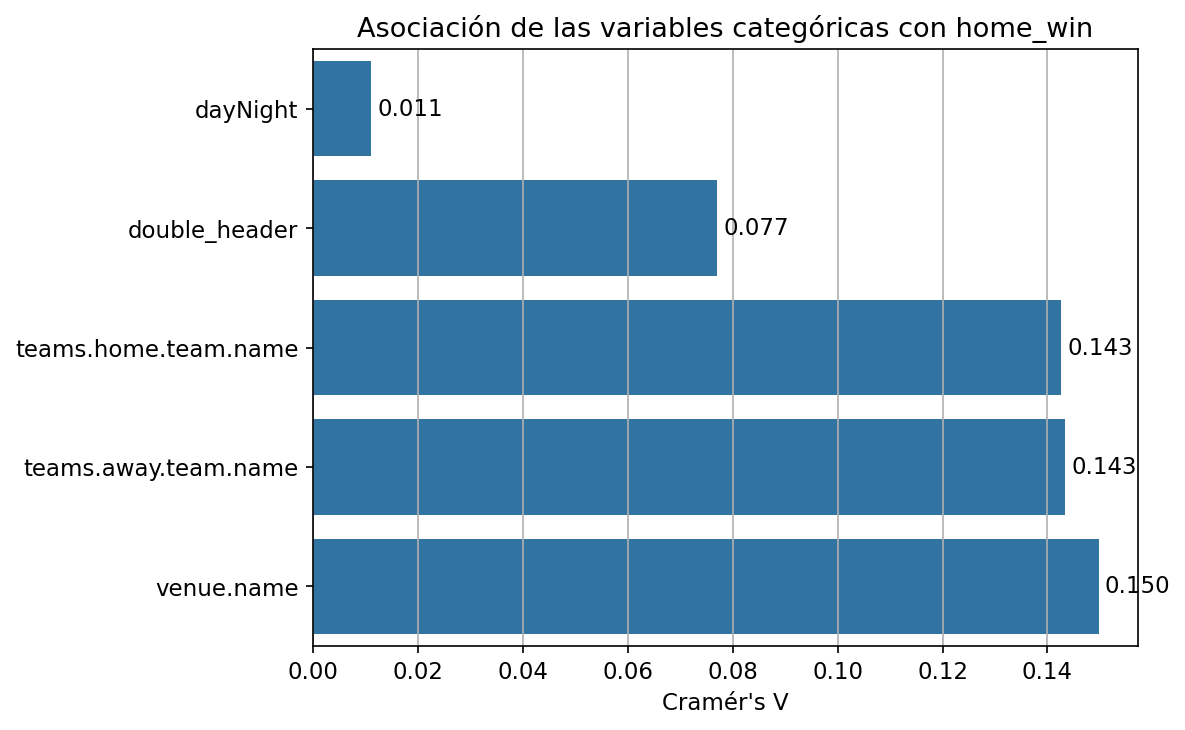

In [411]:
plot_cramer_target = (
    cramer_target
    .sort_values("Cramér's V")
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=plot_cramer_target,
    x="Cramér's V",
    y="Variable"
)

plt.title("Asociación de las variables categóricas con home_win")
plt.xlabel("Cramér's V")
plt.ylabel("")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

save_fig("figura_4_9_cramers_v_target")

### <font color='00FFFF'> 2.5 Variables finales


In [412]:
# ============================================================
# 2.5 CONJUNTO FINAL DE VARIABLES
# ============================================================

target = "home_win"

base_numeric_features = [

    # Contexto del partido
    "seriesGameNumber",

    # Rendimiento histórico
    "win_pct_diff",
    "wins_diff",

    # Baseball Savant
    "xwoba_diff",
    "xba_diff",
    "launch_speed_diff",
    "iso_diff"

]

base_categorical_features = [
    "dayNight",
    "teams.home.team.name",
    "teams.away.team.name"
]

market_feature_groups = {

    "consensus":[
        "home_close_prob_mean"
    ],

    "confidence":[
        "close_market_strength"
    ],

    "movement":[
        "home_line_movement"
    ]

}

In [413]:
feature_summary = pd.DataFrame({

    "Grupo":[

        "Variables numéricas base",

        "Variables categóricas base",

        "Variables del mercado"

    ],

    "Cantidad":[

        len(base_numeric_features),

        len(base_categorical_features),

        sum(
            len(v)
            for v in market_feature_groups.values()
        )

    ]

})

display(feature_summary)

,Grupo,Cantidad
0,Variables numéricas base,7
1,Variables categóricas base,3
2,Variables del mercado,3


In [414]:
feature_summary.to_csv(

    output_path /
    "tabla_4_17_conjunto_variables.csv",

    index=False,

    encoding="utf-8-sig"

)

In [415]:
feature_table = pd.DataFrame({

    "Grupo":[

        "Contexto",

        "Rendimiento histórico",

        "Statcast",

        "Mercado",

        "Variables categóricas"

    ],

    "Variables":[

        "seriesGameNumber",

        "win_pct_diff, wins_diff",

        "xwoba_diff, xba_diff, launch_speed_diff, iso_diff",

        "home_close_prob_mean, close_market_strength, home_line_movement",

        "dayNight, teams.home.team.name, teams.away.team.name"

    ]

})

display(feature_table)

,Grupo,Variables
0,Contexto,seriesGameNumber
1,Rendimiento histórico,"win_pct_diff, wins_diff"
2,Statcast,"xwoba_diff, xba_diff, launch_speed_diff, iso_diff"
3,Mercado,"home_close_prob_mean, close_market_strength, h..."
4,Variables categóricas,"dayNight, teams.home.team.name, teams.away.tea..."


In [416]:
feature_table.to_csv(

    output_path /
    "tabla_4_18_variables_finales.csv",

    index=False,

    encoding="utf-8-sig"

)

In [417]:
experiment_configs = {

    "E1":{

        "Variables":

        len(base_numeric_features)
        +
        len(base_categorical_features)

    },

    "E2":{

        "Variables":

        len(base_numeric_features)
        +
        len(base_categorical_features)
        +
        1

    },

    "E3":{

        "Variables":

        len(base_numeric_features)
        +
        len(base_categorical_features)
        +
        2

    },

    "E4":{

        "Variables":

        len(base_numeric_features)
        +
        len(base_categorical_features)
        +
        3

    }

}

experiment_table = pd.DataFrame({

    "Experimento":[

        "E1",

        "E2",

        "E3",

        "E4"

    ],

    "Variables":[

        experiment_configs["E1"]["Variables"],

        experiment_configs["E2"]["Variables"],

        experiment_configs["E3"]["Variables"],

        experiment_configs["E4"]["Variables"]

    ]

})

display(experiment_table)

,Experimento,Variables
0,E1,10
1,E2,11
2,E3,12
3,E4,13


In [418]:
experiment_table.to_csv(

    output_path /
    "tabla_4_19_experimentos.csv",

    index=False,

    encoding="utf-8-sig"

)

# <font color='00FF00'> 3. DISEÑO EXPERIMENTAL


### <font color='00FFFF'> 3.1 Experimentos E1-E4


### <font color='00FFFF'> 3.2 Modelos evaluados


### <font color='00FFFF'> 3.3 Partición train-test


# <font color='00FF00'> 4. RESULTADOS


### <font color='00FFFF'> 4.1 Análisis del mercado


In [419]:
# ============================================================
# 4.4.1 MERCADO COMO PREDICTOR
# ============================================================

market_summary = (
    df["home_close_prob_mean"]
    .describe()
    .to_frame()
    .T
)

display(
    market_summary.round(4)
)

market_summary.to_csv(
    output_path /
    "tabla_4_20_describe_home_close_prob.csv",
    index=False,
    encoding="utf-8-sig"
)

,count,mean,std,min,25%,50%,75%,max
home_close_prob_mean,5312.0,0.5305,0.0927,0.2171,0.4675,0.5321,0.595,0.7881


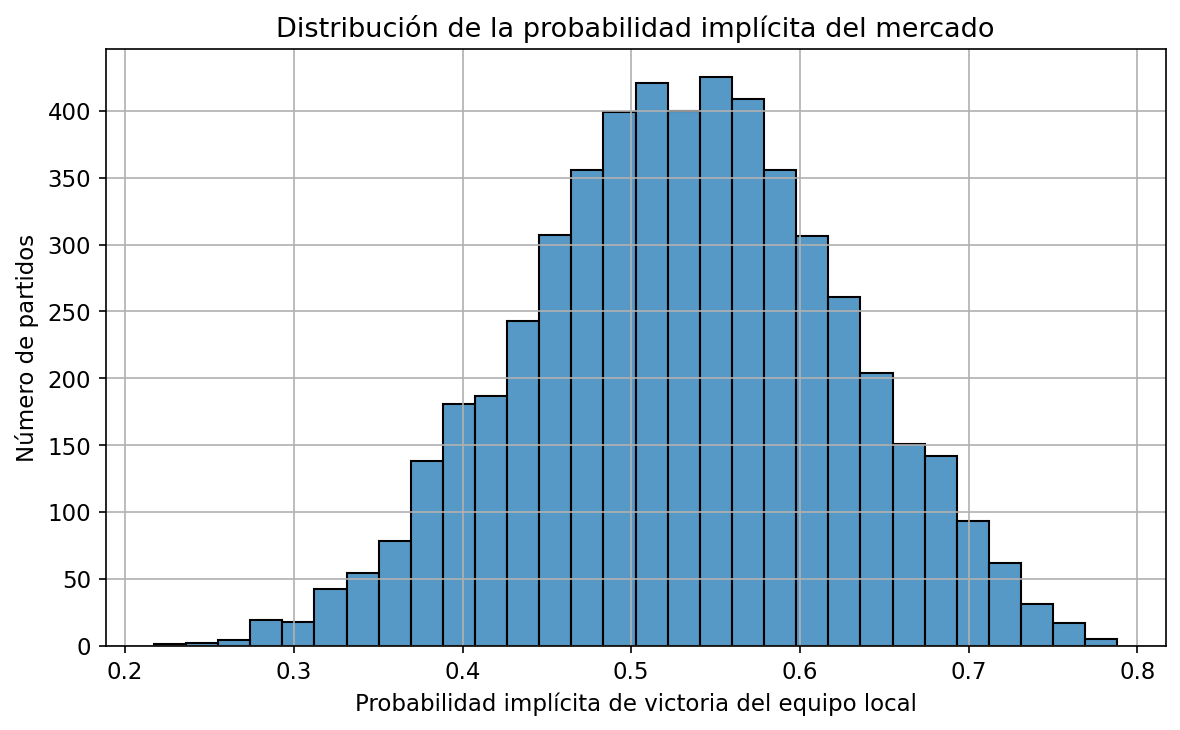

In [420]:
plt.figure(figsize=(8,5))

ax = sns.histplot(

    df["home_close_prob_mean"],

    bins=30

)

plt.xlabel(
    "Probabilidad implícita de victoria del equipo local"
)

plt.ylabel(
    "Número de partidos"
)

plt.title(
    "Distribución de la probabilidad implícita del mercado"
)

save_fig(
    "figura_4_10_distribucion_home_close_prob"
)

Bins

In [421]:
bins = [0,0.40,0.45,0.50,0.55,0.60,0.70,1]

market_bins = (
    pd.cut(
        df["home_close_prob_mean"],
        bins=bins
    )
    .value_counts()
    .sort_index()
    .rename("Partidos")
    .reset_index()
)

display(market_bins)

market_bins.to_csv(

    output_path /
    "tabla_4_21_bins_probabilidades.csv",

    index=False,

    encoding="utf-8-sig"

)

,home_close_prob_mean,Partidos
0,"(0.0, 0.4]",457
1,"(0.4, 0.45]",583
2,"(0.45, 0.5]",929
3,"(0.5, 0.55]",1079
4,"(0.55, 0.6]",1024
5,"(0.6, 0.7]",1062
6,"(0.7, 1.0]",178


Curva de calibración

In [422]:
calibration = (

    df.assign(

        prob_bin=pd.cut(

            df["home_close_prob_mean"],

            bins=np.arange(0.20,0.85,0.05)

        )

    )

    .groupby(
        "prob_bin",
        observed=False
    )

    .agg(

        market_prob=(
            "home_close_prob_mean",
            "mean"
        ),

        actual_win_rate=(
            "home_win",
            "mean"
        ),

        games=(
            "home_win",
            "size"
        )

    )

    .reset_index()

)

display(
    calibration.round(4)
)

calibration.to_csv(

    output_path /
    "tabla_4_22_calibracion.csv",

    index=False,

    encoding="utf-8-sig"

)

,prob_bin,market_prob,actual_win_rate,games
0,"(0.2, 0.25]",0.2299,0.0000,2
1,"(0.25, 0.3]",0.2822,0.2963,27
2,"(0.3, 0.35]",0.3292,0.2883,111
3,"(0.35, 0.4]",0.3794,0.3785,317
4,"(0.4, 0.45]",0.4269,0.4511,583
5,"(0.45, 0.5]",0.4764,0.4763,928
6,"(0.5, 0.55]",0.5248,0.5241,1080
7,"(0.55, 0.6]",0.5732,0.5430,1024
8,"(0.6, 0.65]",0.6225,0.6014,695
9,"(0.65, 0.7]",0.6731,0.6785,367


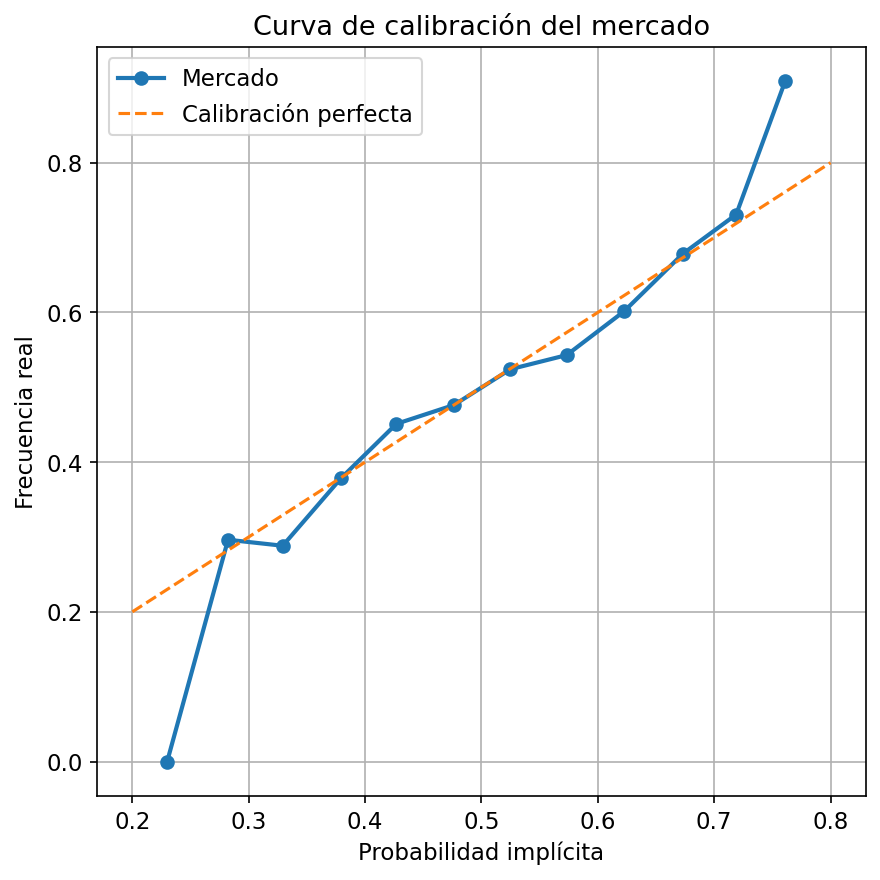

In [423]:
plt.figure(figsize=(6,6))

plt.plot(

    calibration["market_prob"],

    calibration["actual_win_rate"],

    marker="o",

    linewidth=2,

    label="Mercado"

)

plt.plot(

    [0.2,0.8],

    [0.2,0.8],

    "--",

    label="Calibración perfecta"

)

plt.xlabel(
    "Probabilidad implícita"
)

plt.ylabel(
    "Frecuencia real"
)

plt.title(
    "Curva de calibración del mercado"
)

plt.legend()

save_fig(
    "figura_4_11_calibracion"
)

ROC

In [424]:
from sklearn.metrics import roc_auc_score

market_auc = roc_auc_score(

    df["home_win"],

    df["home_close_prob_mean"]

)

market_auc_df = pd.DataFrame({

    "Modelo":[
        "Mercado"
    ],

    "ROC-AUC":[
        market_auc
    ]

})

display(
    market_auc_df.round(4)
)

market_auc_df.to_csv(

    output_path /
    "tabla_4_23_auc_mercado.csv",

    index=False,

    encoding="utf-8-sig"

)

,Modelo,ROC-AUC
0,Mercado,0.598


Curva ROC

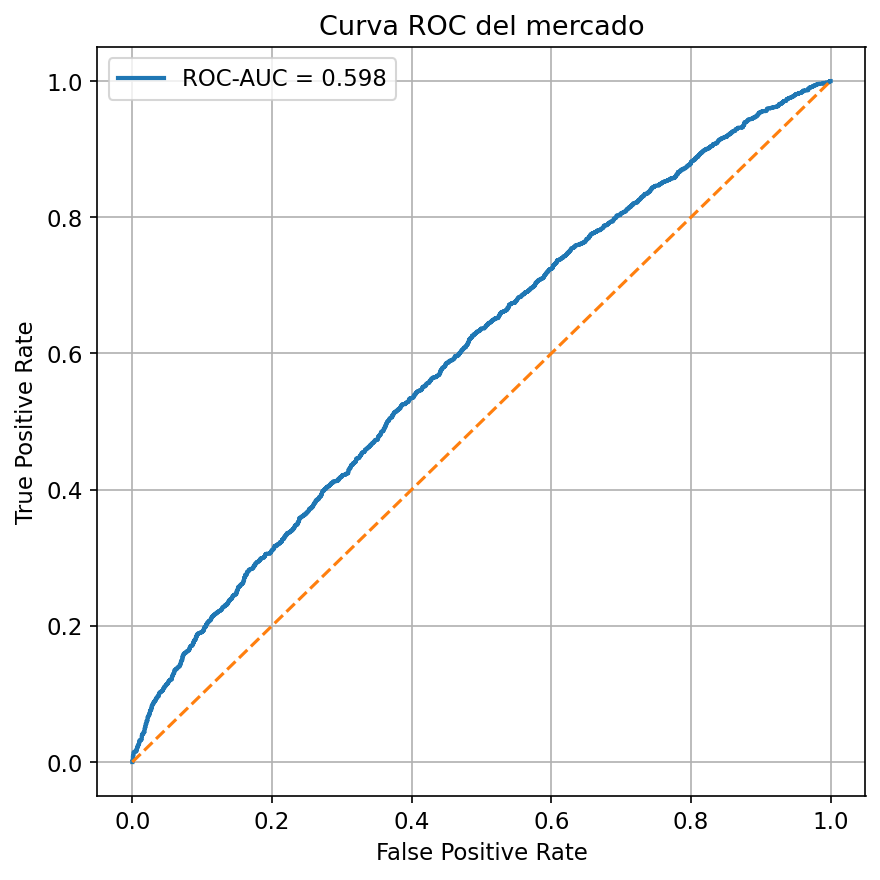

In [425]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(

    df["home_win"],

    df["home_close_prob_mean"]

)

plt.figure(figsize=(6,6))

plt.plot(

    fpr,

    tpr,

    linewidth=2,

    label=f"ROC-AUC = {market_auc:.3f}"

)

plt.plot(

    [0,1],

    [0,1],

    "--"

)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Curva ROC del mercado"
)

plt.legend()

save_fig(
    "figura_4_12_roc_mercado"
)

# <font color='00FF00'> 5. MODELO FINAL


### <font color='00FFFF'> Configuración


In [426]:
# ============================================================
# 4.1 CONFIGURACIÓN DEL EXPERIMENTO
# ============================================================

from sklearn.base import clone

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

### <font color='00FFFF'> Conjuntos de Variables


In [427]:
target = "home_win"

In [428]:
base_numeric_features = [
    "seriesGameNumber",
    "win_pct_diff",
    "wins_diff",
    "xwoba_diff",
    "xba_diff",
    "launch_speed_diff",
    "iso_diff"
]

base_categorical_features = [
    "dayNight",
    "teams.home.team.name",
    "teams.away.team.name"
]

market_feature_groups = {
    "consensus":[
        "home_close_prob_mean"
    ],
    "confidence":[
        "close_market_strength"
    ],
    "movement":[
        "home_line_movement"
    ]
}

### <font color='00FFFF'> Experimentos


In [429]:
# ============================================================
# CONFIGURACIÓN DE EXPERIMENTOS
# ============================================================

experiment_configs = {

    "E1_Base": {
        "description": "Stats API + Baseball Savant",
        "added_feature": "Ninguna",
        "numeric_features": (
            base_numeric_features.copy()
        ),
        "categorical_features": (
            base_categorical_features.copy()
        )
    },

    "E2_Consensus": {
        "description": "Modelo base + consenso de cierre del mercado",
        "added_feature": "home_close_prob_mean",
        "numeric_features": (
            base_numeric_features
            + market_feature_groups["consensus"]
        ),
        "categorical_features": (
            base_categorical_features.copy()
        )
    },

    "E3_Confidence": {
        "description": (
            "Modelo base + consenso de cierre "
            "+ fortaleza del mercado"
        ),
        "added_feature": "close_market_strength",
        "numeric_features": (
            base_numeric_features
            + market_feature_groups["consensus"]
            + market_feature_groups["confidence"]
        ),
        "categorical_features": (
            base_categorical_features.copy()
        )
    },

    "E4_Movement": {
        "description": (
            "Modelo base + consenso de cierre "
            "+ fortaleza del mercado "
            "+ movimiento de línea"
        ),
        "added_feature": "home_line_movement",
        "numeric_features": (
            base_numeric_features
            + market_feature_groups["consensus"]
            + market_feature_groups["confidence"]
            + market_feature_groups["movement"]
        ),
        "categorical_features": (
            base_categorical_features.copy()
        )
    }
}

### <font color='00FFFF'> Partición


In [430]:
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.20,
    random_state=42,
    stratify=df[target]
)

print("Train:",len(train_idx))
print("Test :",len(test_idx))

Train: 4249
Test : 1063


In [431]:
split_summary = pd.DataFrame({
    "Conjunto":[
        "Entrenamiento",
        "Prueba"
    ],
    "Observaciones":[
        len(train_idx),
        len(test_idx)
    ],
    "Proporción home_win":[
        df.loc[train_idx,target].mean(),
        df.loc[test_idx,target].mean()
    ]

})

display(
    split_summary.round(4)
)

,Conjunto,Observaciones,Proporción home_win
0,Entrenamiento,4249,0.5248
1,Prueba,1063,0.5249


In [432]:
split_summary.to_csv(
    output_path /
    "tabla_4_20_train_test.csv",
    index=False,
    encoding="utf-8-sig"
)

## <font color='00FF00'> FUNCIÓN GENERAL DE ENTRENAMIENTO



## <font color='00FF00'> E1 — Modelo Base



In [433]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (StandardScaler,OneHotEncoder)
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def run_experiment(
    df,
    experiment_name,
    description,
    numeric_features,
    categorical_features,
    target,
    train_idx,
    test_idx,
    estimator
):

    selected_features = (
        numeric_features
        +
        categorical_features
    )

    X = df[selected_features].copy()
    y = df[target].copy()
    X_train = X.loc[train_idx]
    X_test = X.loc[test_idx]
    y_train = y.loc[train_idx]
    y_test = y.loc[test_idx]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                StandardScaler(),
                numeric_features
            ),

            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),

                categorical_features
            )
        ]
    )

    pipeline = Pipeline([
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            clone(estimator)
        )
    ])

    pipeline.fit(
        X_train,
        y_train
    )

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(
        X_test
    )[:,1]

    metrics = {

        "experiment":experiment_name,
        "description":description,
        "model_name":
            estimator.__class__.__name__,
        "accuracy":
            accuracy_score(
                y_test,
                y_pred
            ),
        "precision":
            precision_score(
                y_test,
                y_pred
            ),
        "recall":
            recall_score(
                y_test,
                y_pred
            ),
        "f1":
            f1_score(
                y_test,
                y_pred
            ),
        "roc_auc":
            roc_auc_score(
                y_test,
                y_prob
            )

    }

    return {
        "metrics":metrics,
        "pipeline":pipeline,
        "y_test":y_test,
        "y_pred":y_pred,
        "y_prob":y_prob
    }

### <font color='00FFFF'> Modelos


In [434]:
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

estimators = {

    "Logistic Regression":

        LogisticRegression(

            max_iter=1000,

            random_state=42

        ),

    "Random Forest":

        RandomForestClassifier(

            n_estimators=300,

            random_state=42,

            class_weight="balanced",

            n_jobs=-1

        ),

    "XGBoost":

        XGBClassifier(

            n_estimators=300,

            max_depth=4,

            learning_rate=0.05,

            subsample=0.8,

            colsample_bytree=0.8,

            eval_metric="logloss",

            random_state=42,

            n_jobs=-1

        )

}

In [435]:
estimators = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ),

    "XGBoost":

        XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )
}

### <font color='00FFFF'> Entrenamiento


In [436]:

all_experiment_results = {}

for model_name, estimator in estimators.items():
    for experiment_name, config in experiment_configs.items():
        result = run_experiment(
            df=df,
            experiment_name=experiment_name,
            description=config["description"],
            numeric_features=config["numeric_features"],
            categorical_features=config["categorical_features"],
            target=target,
            train_idx=train_idx,
            test_idx=test_idx,
            estimator=estimator

        )

        result["metrics"]["model_name"] = model_name

        result["metrics"]["n_numeric_features"] = (
            len(config["numeric_features"])
        )

        result["metrics"]["n_categorical_features"] = (
            len(config["categorical_features"])
        )

        result["metrics"]["added_feature"] = (
            config["added_feature"]
        )

        all_experiment_results[
            f"{model_name}_{experiment_name}"
        ] = result

In [437]:
results_df = pd.DataFrame(
    [
        result["metrics"]
        for result in all_experiment_results.values()
    ]
)

results_df = results_df[
    [
        "model_name",
        "experiment",
        "description",
        "added_feature",
        "n_numeric_features",
        "n_categorical_features",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ]
]

results_df = (
    results_df
    .sort_values(
        by=["model_name", "experiment"]
    )
    .reset_index(drop=True)
)

display(results_df.round(4))

,model_name,experiment,description,added_feature,n_numeric_features,n_categorical_features,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,E1_Base,Stats API + Baseball Savant,Ninguna,7,3,0.5466,0.5617,0.6201,0.5894,0.5631
1,Logistic Regression,E2_Consensus,Modelo base + consenso de cierre del mercado,home_close_prob_mean,8,3,0.5691,0.5806,0.6452,0.6112,0.5796
2,Logistic Regression,E3_Confidence,Modelo base + consenso de cierre + fortaleza d...,close_market_strength,9,3,0.5691,0.5806,0.6452,0.6112,0.5799
3,Logistic Regression,E4_Movement,Modelo base + consenso de cierre + fortaleza d...,home_line_movement,10,3,0.5560,0.5712,0.6183,0.5938,0.5773
4,Random Forest,E1_Base,Stats API + Baseball Savant,Ninguna,7,3,0.5240,0.5435,0.5824,0.5623,0.5296
5,Random Forest,E2_Consensus,Modelo base + consenso de cierre del mercado,home_close_prob_mean,8,3,0.5343,0.5535,0.5842,0.5684,0.5402
6,Random Forest,E3_Confidence,Modelo base + consenso de cierre + fortaleza d...,close_market_strength,9,3,0.5400,0.5592,0.5842,0.5714,0.5451
7,Random Forest,E4_Movement,Modelo base + consenso de cierre + fortaleza d...,home_line_movement,10,3,0.5343,0.5550,0.5699,0.5623,0.5487
8,XGBoost,E1_Base,Stats API + Baseball Savant,Ninguna,7,3,0.5381,0.5538,0.6183,0.5843,0.5476
9,XGBoost,E2_Consensus,Modelo base + consenso de cierre del mercado,home_close_prob_mean,8,3,0.5372,0.5571,0.5771,0.5669,0.5526


### <font color='00FFFF'> Benchmark del mercado de apuestas


In [438]:
# ============================================================
# 5.1 BENCHMARK DEL MERCADO DE APUESTAS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Mismas observaciones utilizadas en el conjunto de prueba
y_test_market = df.loc[test_idx, target].copy()

# Probabilidad implícita de cierre del equipo local
market_prob = (
    df.loc[test_idx, "home_close_prob_mean"]
    .copy()
)

# Predicción binaria utilizando el umbral natural de 0.50
market_pred = (
    market_prob >= 0.50
).astype(int)

market_metrics = pd.DataFrame({
    "model_name": ["Mercado de apuestas"],
    "experiment": ["Market_Benchmark"],
    "description": [
        "Probabilidad implícita de cierre como predictor aislado"
    ],
    "added_feature": ["home_close_prob_mean"],
    "n_numeric_features": [1],
    "n_categorical_features": [0],
    "accuracy": [
        accuracy_score(y_test_market, market_pred)
    ],
    "precision": [
        precision_score(y_test_market, market_pred)
    ],
    "recall": [
        recall_score(y_test_market, market_pred)
    ],
    "f1": [
        f1_score(y_test_market, market_pred)
    ],
    "roc_auc": [
        roc_auc_score(y_test_market, market_prob)
    ]
})

display(market_metrics.round(4))

,model_name,experiment,description,added_feature,n_numeric_features,n_categorical_features,accuracy,precision,recall,f1,roc_auc
0,Mercado de apuestas,Market_Benchmark,Probabilidad implícita de cierre como predicto...,home_close_prob_mean,1,0,0.588,0.5904,0.7025,0.6416,0.609


In [439]:
market_metrics.to_csv(
    output_path / "tabla_4_23_benchmark_mercado.csv",
    index=False,
    encoding="utf-8-sig"
)

In [440]:
# ============================================================
# RESULTADOS COMPLETOS: MODELOS + MERCADO
# ============================================================

results_with_market = pd.concat(
    [
        results_df,
        market_metrics
    ],
    ignore_index=True
)

display(
    results_with_market[
        [
            "model_name",
            "experiment",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ]
    ].round(4)
)

,model_name,experiment,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,E1_Base,0.5466,0.5617,0.6201,0.5894,0.5631
1,Logistic Regression,E2_Consensus,0.5691,0.5806,0.6452,0.6112,0.5796
2,Logistic Regression,E3_Confidence,0.5691,0.5806,0.6452,0.6112,0.5799
3,Logistic Regression,E4_Movement,0.5560,0.5712,0.6183,0.5938,0.5773
4,Random Forest,E1_Base,0.5240,0.5435,0.5824,0.5623,0.5296
5,Random Forest,E2_Consensus,0.5343,0.5535,0.5842,0.5684,0.5402
6,Random Forest,E3_Confidence,0.5400,0.5592,0.5842,0.5714,0.5451
7,Random Forest,E4_Movement,0.5343,0.5550,0.5699,0.5623,0.5487
8,XGBoost,E1_Base,0.5381,0.5538,0.6183,0.5843,0.5476
9,XGBoost,E2_Consensus,0.5372,0.5571,0.5771,0.5669,0.5526


In [441]:
results_with_market.to_csv(
    output_path / "tabla_4_24_resultados_modelos_y_mercado.csv",
    index=False,
    encoding="utf-8-sig"
)

In [442]:
results_clean = (
    results_with_market[
        [
            "model_name",
            "experiment",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ]
    ]
    .rename(columns={
        "model_name": "Modelo",
        "experiment": "Experimento",
        "accuracy": "Accuracy",
        "precision": "Precision",
        "recall": "Recall",
        "f1": "F1",
        "roc_auc": "ROC-AUC"
    })
)

display(results_clean.round(4))

,Modelo,Experimento,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,E1_Base,0.5466,0.5617,0.6201,0.5894,0.5631
1,Logistic Regression,E2_Consensus,0.5691,0.5806,0.6452,0.6112,0.5796
2,Logistic Regression,E3_Confidence,0.5691,0.5806,0.6452,0.6112,0.5799
3,Logistic Regression,E4_Movement,0.5560,0.5712,0.6183,0.5938,0.5773
4,Random Forest,E1_Base,0.5240,0.5435,0.5824,0.5623,0.5296
5,Random Forest,E2_Consensus,0.5343,0.5535,0.5842,0.5684,0.5402
6,Random Forest,E3_Confidence,0.5400,0.5592,0.5842,0.5714,0.5451
7,Random Forest,E4_Movement,0.5343,0.5550,0.5699,0.5623,0.5487
8,XGBoost,E1_Base,0.5381,0.5538,0.6183,0.5843,0.5476
9,XGBoost,E2_Consensus,0.5372,0.5571,0.5771,0.5669,0.5526


In [443]:
results_clean.to_csv(
    output_path / "tabla_4_25_resultados_completos_limpios.csv",
    index=False,
    encoding="utf-8-sig"
)

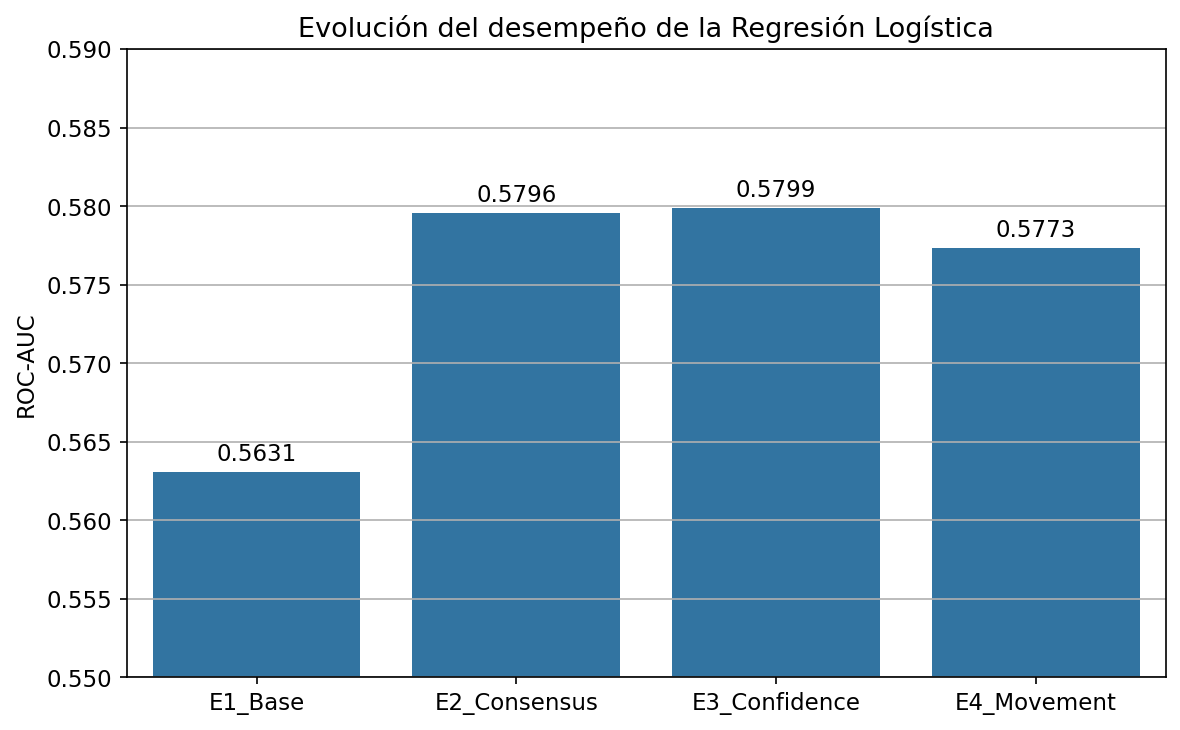

In [444]:
# ============================================================
# FIGURA
# EVOLUCIÓN DEL MODELO LOGÍSTICO
# ============================================================

logistic = (
    results_df[
        results_df["model_name"]=="Logistic Regression"
    ]
    .copy()
)

plt.figure(figsize=(8,5))

ax = sns.barplot(

    data=logistic,

    x="experiment",

    y="roc_auc"

)

plt.ylim(0.55,0.59)

plt.title(
    "Evolución del desempeño de la Regresión Logística"
)

plt.xlabel("")

plt.ylabel("ROC-AUC")

for container in ax.containers:

    ax.bar_label(

        container,

        fmt="%.4f",

        padding=3

    )

save_fig(
    "figura_4_13_logistic_progression"
)

In [445]:
logistic_table = logistic[
    [
        "experiment",

        "added_feature",

        "accuracy",

        "precision",

        "recall",

        "f1",

        "roc_auc"

    ]
]

display(
    logistic_table.round(4)
)

logistic_table.to_csv(

    output_path /
    "tabla_4_23_logistic_progression.csv",

    index=False,

    encoding="utf-8-sig"

)

,experiment,added_feature,accuracy,precision,recall,f1,roc_auc
0,E1_Base,Ninguna,0.5466,0.5617,0.6201,0.5894,0.5631
1,E2_Consensus,home_close_prob_mean,0.5691,0.5806,0.6452,0.6112,0.5796
2,E3_Confidence,close_market_strength,0.5691,0.5806,0.6452,0.6112,0.5799
3,E4_Movement,home_line_movement,0.5560,0.5712,0.6183,0.5938,0.5773


In [446]:
improvement = pd.DataFrame({

    "Variable incorporada":[

        "Modelo Base",

        "Closing Probability",

        "Market Strength",

        "Line Movement"

    ],

    "ROC-AUC":[

        logistic.iloc[0]["roc_auc"],

        logistic.iloc[1]["roc_auc"],

        logistic.iloc[2]["roc_auc"],

        logistic.iloc[3]["roc_auc"]

    ]

})

display(improvement)

,Variable incorporada,ROC-AUC
0,Modelo Base,0.563086
1,Closing Probability,0.579588
2,Market Strength,0.579886
3,Line Movement,0.577320


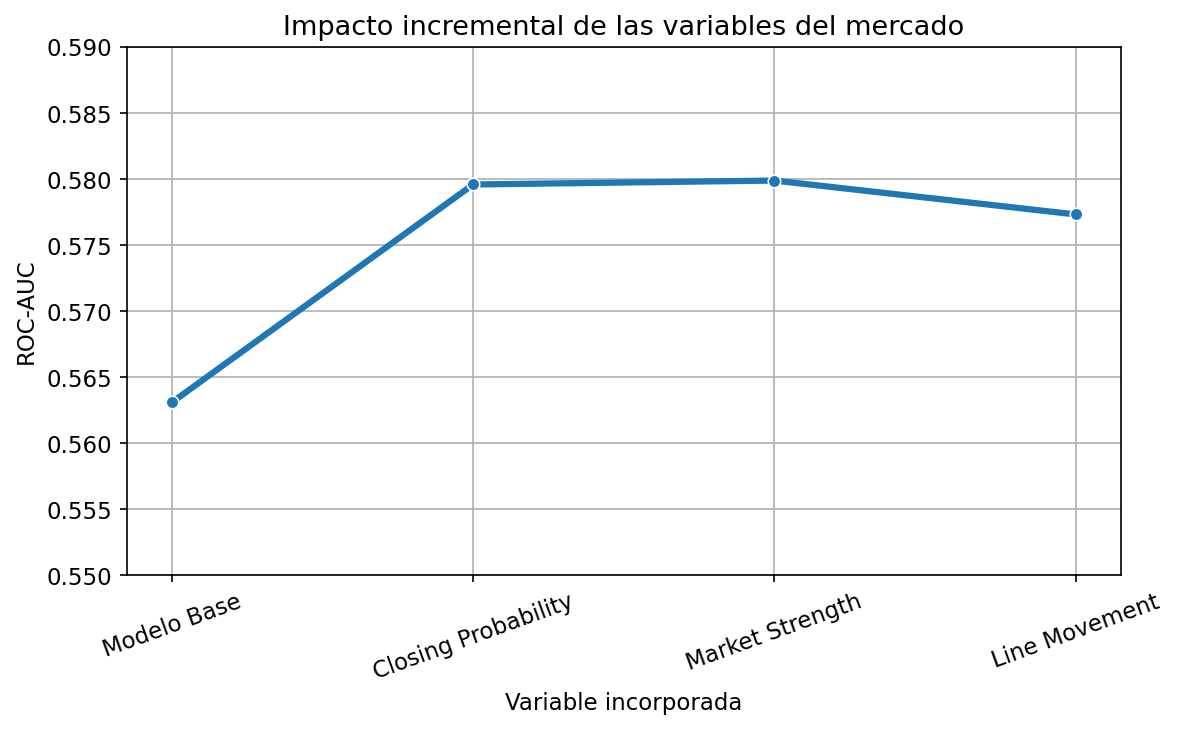

In [447]:
plt.figure(figsize=(8,5))

ax = sns.lineplot(

    data=improvement,

    x="Variable incorporada",

    y="ROC-AUC",

    marker="o",

    linewidth=3

)

plt.ylim(0.55,0.59)

plt.title(
    "Impacto incremental de las variables del mercado"
)

plt.xticks(rotation=20)

save_fig(
    "figura_4_14_incremento_logistic"
)

### <font color='00FFFF'> Comparación entre algoritmos


In [448]:
# ============================================================
# 4.4.3 COMPARACIÓN ENTRE ALGORITMOS
# ============================================================

algorithm_summary = (
    results_df
    .groupby("model_name")
    .agg(
        Mejor_ROC_AUC=("roc_auc","max"),
        Mejor_Accuracy=("accuracy","max"),
        Experimentos=("experiment","count")
    )
    .reset_index()
)

display(
    algorithm_summary.round(4)
)

algorithm_summary.to_csv(

    output_path /

    "tabla_4_24_resumen_algoritmos.csv",

    index=False,

    encoding="utf-8-sig"

)

,model_name,Mejor_ROC_AUC,Mejor_Accuracy,Experimentos
0,Logistic Regression,0.5799,0.5691,4
1,Random Forest,0.5487,0.5400,4
2,XGBoost,0.5526,0.5428,4


In [449]:
best_per_experiment = (
    results_df.loc[
        results_df.groupby(
            "experiment"
        )["roc_auc"].idxmax()
    ]
)

display(
    best_per_experiment[
        [
            "experiment",
            "model_name",
            "roc_auc",
            "accuracy"
        ]
    ].round(4)
)

best_per_experiment.to_csv(

    output_path /

    "tabla_4_25_mejor_modelo_por_experimento.csv",

    index=False,

    encoding="utf-8-sig"

)

,experiment,model_name,roc_auc,accuracy
0,E1_Base,Logistic Regression,0.5631,0.5466
1,E2_Consensus,Logistic Regression,0.5796,0.5691
2,E3_Confidence,Logistic Regression,0.5799,0.5691
3,E4_Movement,Logistic Regression,0.5773,0.5560


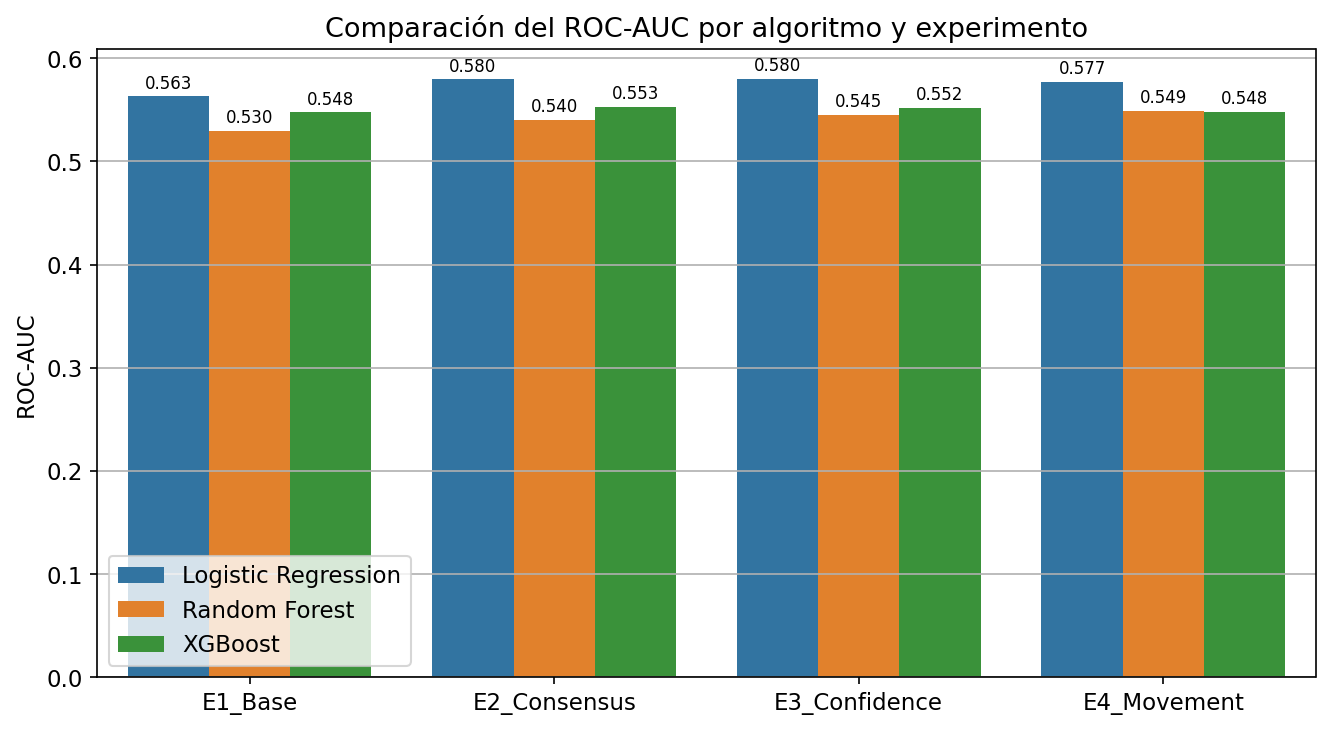

In [450]:
plt.figure(figsize=(9,5))

ax = sns.barplot(

    data=results_df,

    x="experiment",

    y="roc_auc",

    hue="model_name"

)

plt.title(
    "Comparación del ROC-AUC por algoritmo y experimento"
)

plt.ylabel("ROC-AUC")

plt.xlabel("")

for container in ax.containers:

    ax.bar_label(

        container,

        fmt="%.3f",

        fontsize=8,

        padding=2

    )

plt.legend(title="")

save_fig(
    "figura_4_15_algoritmos_experimentos"
)

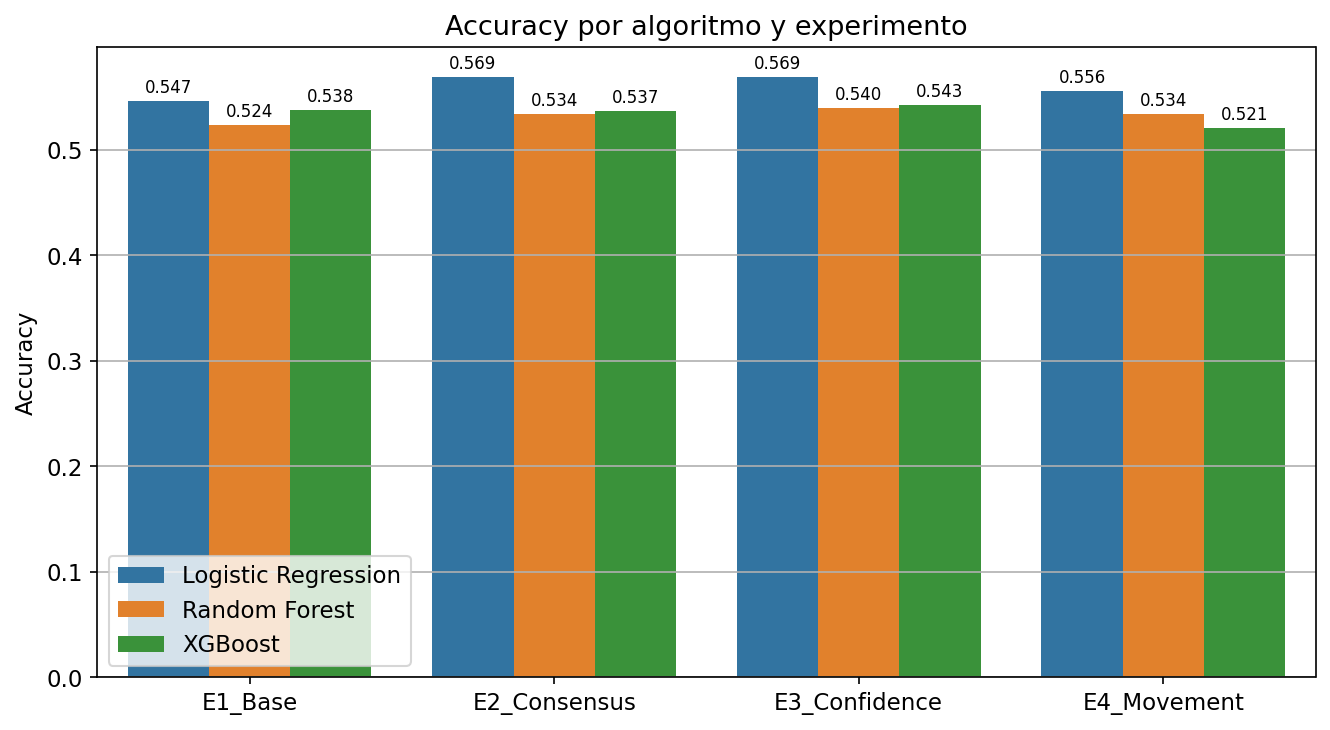

In [451]:
plt.figure(figsize=(9,5))

ax = sns.barplot(

    data=results_df,

    x="experiment",

    y="accuracy",

    hue="model_name"

)

plt.title(
    "Accuracy por algoritmo y experimento"
)

plt.ylabel("Accuracy")

plt.xlabel("")

for container in ax.containers:

    ax.bar_label(

        container,

        fmt="%.3f",

        fontsize=8,

        padding=2

    )

plt.legend(title="")

save_fig(
    "figura_4_16_accuracy_algoritmos"
)

In [452]:
ranking = (
    results_df[
        [
            "model_name",

            "experiment",

            "roc_auc"
        ]
    ]

    .sort_values(
        "roc_auc",
        ascending=False
    )

    .reset_index(drop=True)
)

display(
    ranking.round(4)
)

ranking.to_csv(

    output_path /

    "tabla_4_26_ranking_modelos.csv",

    index=False,

    encoding="utf-8-sig"

)

,model_name,experiment,roc_auc
0,Logistic Regression,E3_Confidence,0.5799
1,Logistic Regression,E2_Consensus,0.5796
2,Logistic Regression,E4_Movement,0.5773
3,Logistic Regression,E1_Base,0.5631
4,XGBoost,E2_Consensus,0.5526
5,XGBoost,E3_Confidence,0.5516
6,Random Forest,E4_Movement,0.5487
7,XGBoost,E4_Movement,0.5480
8,XGBoost,E1_Base,0.5476
9,Random Forest,E3_Confidence,0.5451


In [453]:
# ============================================================
# 4.4.2 COMPARACIÓN DE MODELOS BASE
# ============================================================

base_results = (
    results_df[
        results_df["experiment"] == "E1_Base"
    ]
    .copy()
    .sort_values(
        "roc_auc",
        ascending=False
    )
    .reset_index(drop=True)
)

base_results.insert(
    0,
    "Posición",
    range(1, len(base_results) + 1)
)

base_results_clean = (
    base_results[
        [
            "Posición",
            "model_name",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ]
    ]
    .rename(columns={
        "model_name": "Modelo",
        "accuracy": "Accuracy",
        "precision": "Precision",
        "recall": "Recall",
        "f1": "F1",
        "roc_auc": "ROC-AUC"
    })
)

display(base_results_clean.round(4))

,Posición,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC
0,1,Logistic Regression,0.5466,0.5617,0.6201,0.5894,0.5631
1,2,XGBoost,0.5381,0.5538,0.6183,0.5843,0.5476
2,3,Random Forest,0.5240,0.5435,0.5824,0.5623,0.5296


In [454]:
base_results_clean.to_csv(
    output_path / "tabla_4_23_comparacion_modelos_base.csv",
    index=False,
    encoding="utf-8-sig"
)

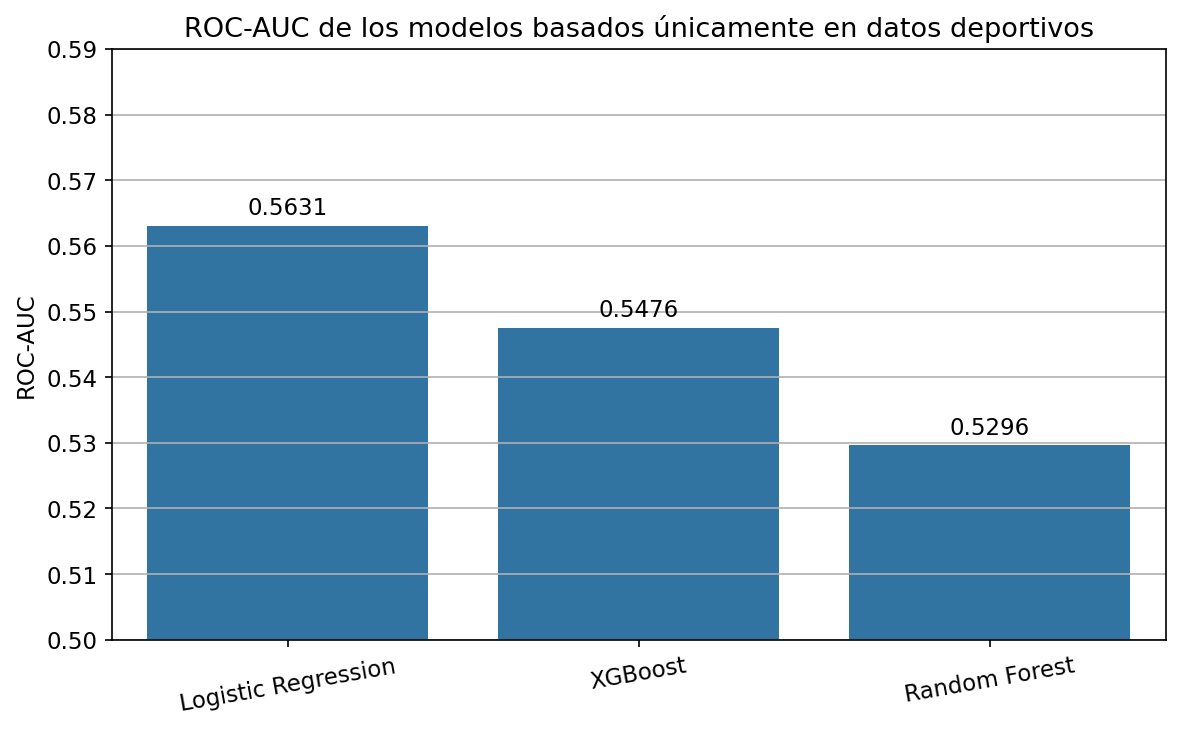

In [455]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=base_results,
    x="model_name",
    y="roc_auc"
)

plt.title("ROC-AUC de los modelos basados únicamente en datos deportivos")
plt.xlabel("")
plt.ylabel("ROC-AUC")
plt.ylim(0.50, 0.59)
plt.xticks(rotation=10)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=3
    )

save_fig("figura_4_13_roc_auc_modelos_base")

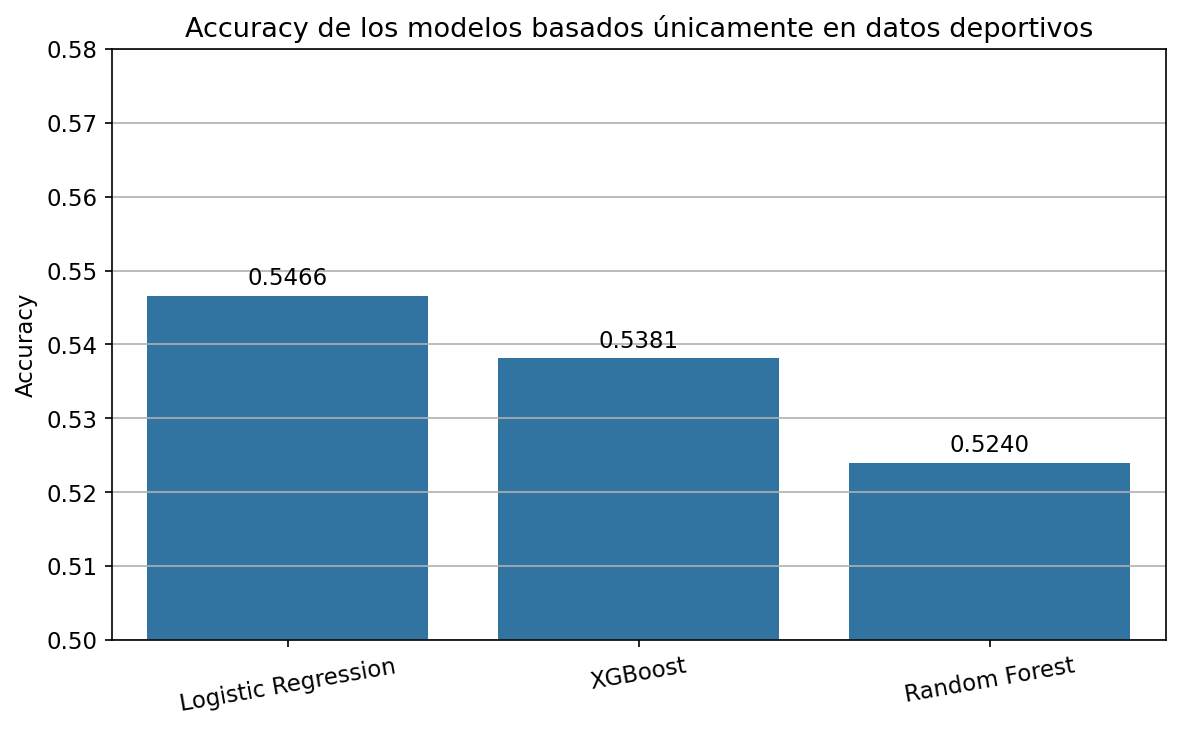

In [456]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=base_results,
    x="model_name",
    y="accuracy"
)

plt.title("Accuracy de los modelos basados únicamente en datos deportivos")
plt.xlabel("")
plt.ylabel("Accuracy")
plt.ylim(0.50, 0.58)
plt.xticks(rotation=10)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=3
    )

save_fig("figura_4_14_accuracy_modelos_base")

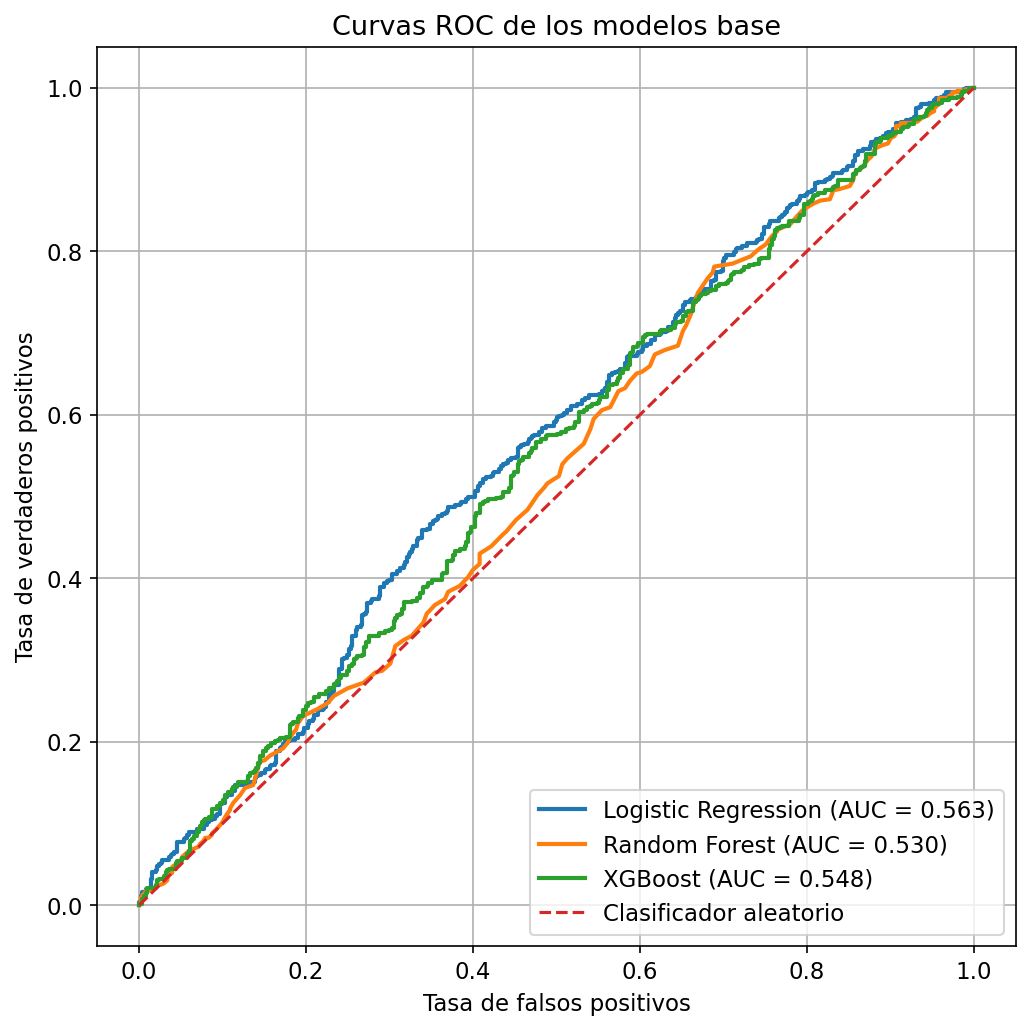

In [457]:
# ============================================================
# CURVAS ROC DE LOS MODELOS BASE
# ============================================================

from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(7, 7))

base_model_names = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
]

for model_name in base_model_names:

    result_key = f"{model_name}_E1_Base"

    result = all_experiment_results[result_key]

    y_test_base = result["y_test"]
    y_prob_base = result["y_prob"]

    fpr, tpr, _ = roc_curve(
        y_test_base,
        y_prob_base
    )

    model_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {model_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Clasificador aleatorio"
)

plt.title("Curvas ROC de los modelos base")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend(loc="lower right")

save_fig("figura_4_15_curvas_roc_modelos_base")

In [458]:
# ============================================================
# MATRIZ ROC-AUC POR EXPERIMENTO Y MODELO
# ============================================================

experiment_order = [
    "E1_Base",
    "E2_Consensus",
    "E3_Confidence",
    "E4_Movement"
]

model_order = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
]

roc_auc_matrix = (
    results_df
    .pivot_table(
        index="experiment",
        columns="model_name",
        values="roc_auc"
    )
    .reindex(
        index=experiment_order,
        columns=model_order
    )
)

roc_auc_matrix.index = [
    "E1 — Modelo base",
    "E2 — Consenso",
    "E3 — Confianza",
    "E4 — Movimiento"
]

display(roc_auc_matrix.round(4))

model_name,Logistic Regression,Random Forest,XGBoost
E1 — Modelo base,0.5631,0.5296,0.5476
E2 — Consenso,0.5796,0.5402,0.5526
E3 — Confianza,0.5799,0.5451,0.5516
E4 — Movimiento,0.5773,0.5487,0.5480


In [459]:
roc_auc_matrix.round(4).to_csv(
    output_path / "tabla_4_24_roc_auc_por_experimento.csv",
    encoding="utf-8-sig"
)

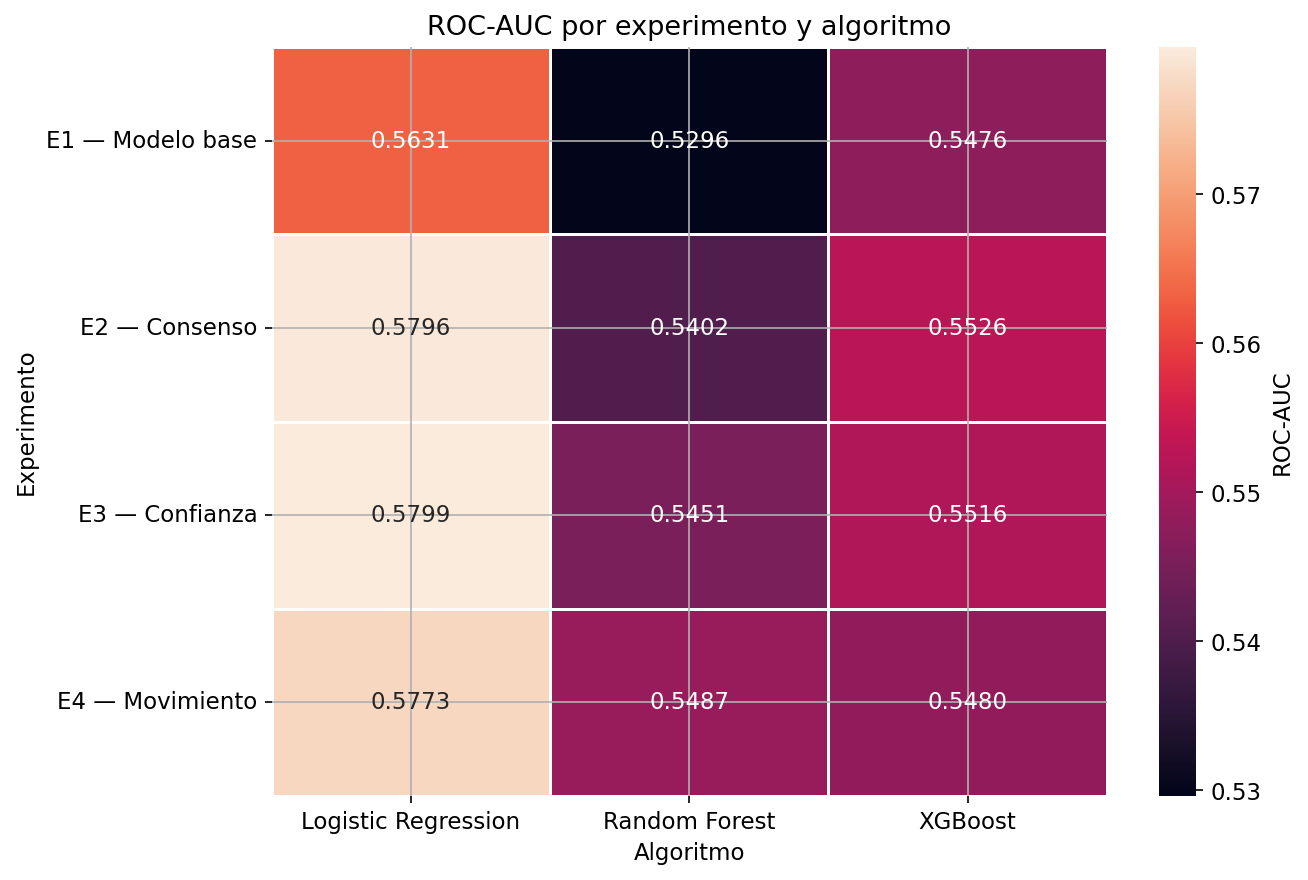

In [460]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    roc_auc_matrix,
    annot=True,
    fmt=".4f",
    linewidths=0.5,
    cbar_kws={
        "label": "ROC-AUC"
    }
)

plt.title("ROC-AUC por experimento y algoritmo")
plt.xlabel("Algoritmo")
plt.ylabel("Experimento")

save_fig("figura_4_16_heatmap_roc_auc_experimentos")

In [461]:
# ============================================================
# IMPACTO INCREMENTAL DE LAS VARIABLES DEL MERCADO
# ============================================================

impact_rows = []

market_steps = [
    {
        "experiment": "E2_Consensus",
        "previous_experiment": "E1_Base",
        "variable": "home_close_prob_mean",
        "dimension": "Consenso del mercado"
    },
    {
        "experiment": "E3_Confidence",
        "previous_experiment": "E2_Consensus",
        "variable": "close_market_strength",
        "dimension": "Fortaleza del mercado"
    },
    {
        "experiment": "E4_Movement",
        "previous_experiment": "E3_Confidence",
        "variable": "home_line_movement",
        "dimension": "Movimiento de línea"
    }
]

for step in market_steps:

    for model_name in model_order:

        current_row = results_df[
            (results_df["model_name"] == model_name)
            & (results_df["experiment"] == step["experiment"])
        ].iloc[0]

        previous_row = results_df[
            (results_df["model_name"] == model_name)
            & (
                results_df["experiment"]
                == step["previous_experiment"]
            )
        ].iloc[0]

        impact_rows.append({
            "Dimensión del mercado": step["dimension"],
            "Variable incorporada": step["variable"],
            "Modelo": model_name,
            "Delta Accuracy": (
                current_row["accuracy"]
                - previous_row["accuracy"]
            ),
            "Delta ROC-AUC": (
                current_row["roc_auc"]
                - previous_row["roc_auc"]
            )
        })

market_impact_long = pd.DataFrame(impact_rows)

display(market_impact_long.round(4))

,Dimensión del mercado,Variable incorporada,Modelo,Delta Accuracy,Delta ROC-AUC
0,Consenso del mercado,home_close_prob_mean,Logistic Regression,0.0226,0.0165
1,Consenso del mercado,home_close_prob_mean,Random Forest,0.0103,0.0106
2,Consenso del mercado,home_close_prob_mean,XGBoost,-0.0009,0.0050
3,Fortaleza del mercado,close_market_strength,Logistic Regression,0.0000,0.0003
4,Fortaleza del mercado,close_market_strength,Random Forest,0.0056,0.0050
5,Fortaleza del mercado,close_market_strength,XGBoost,0.0056,-0.0010
6,Movimiento de línea,home_line_movement,Logistic Regression,-0.0132,-0.0026
7,Movimiento de línea,home_line_movement,Random Forest,-0.0056,0.0036
8,Movimiento de línea,home_line_movement,XGBoost,-0.0216,-0.0036


In [462]:
market_impact_long.to_csv(
    output_path / "tabla_4_25_impacto_incremental_mercado_detalle.csv",
    index=False,
    encoding="utf-8-sig"
)

In [463]:
market_impact_table = (
    market_impact_long
    .pivot_table(
        index=[
            "Dimensión del mercado",
            "Variable incorporada"
        ],
        columns="Modelo",
        values="Delta ROC-AUC"
    )
    .reset_index()
)

market_impact_table = market_impact_table[
    [
        "Dimensión del mercado",
        "Variable incorporada",
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ]
]

display(market_impact_table.round(4))

Modelo,Dimensión del mercado,Variable incorporada,Logistic Regression,Random Forest,XGBoost
0,Consenso del mercado,home_close_prob_mean,0.0165,0.0106,0.0050
1,Fortaleza del mercado,close_market_strength,0.0003,0.0050,-0.0010
2,Movimiento de línea,home_line_movement,-0.0026,0.0036,-0.0036


In [464]:
market_impact_table.round(4).to_csv(
    output_path / "tabla_4_26_impacto_variables_mercado.csv",
    index=False,
    encoding="utf-8-sig"
)

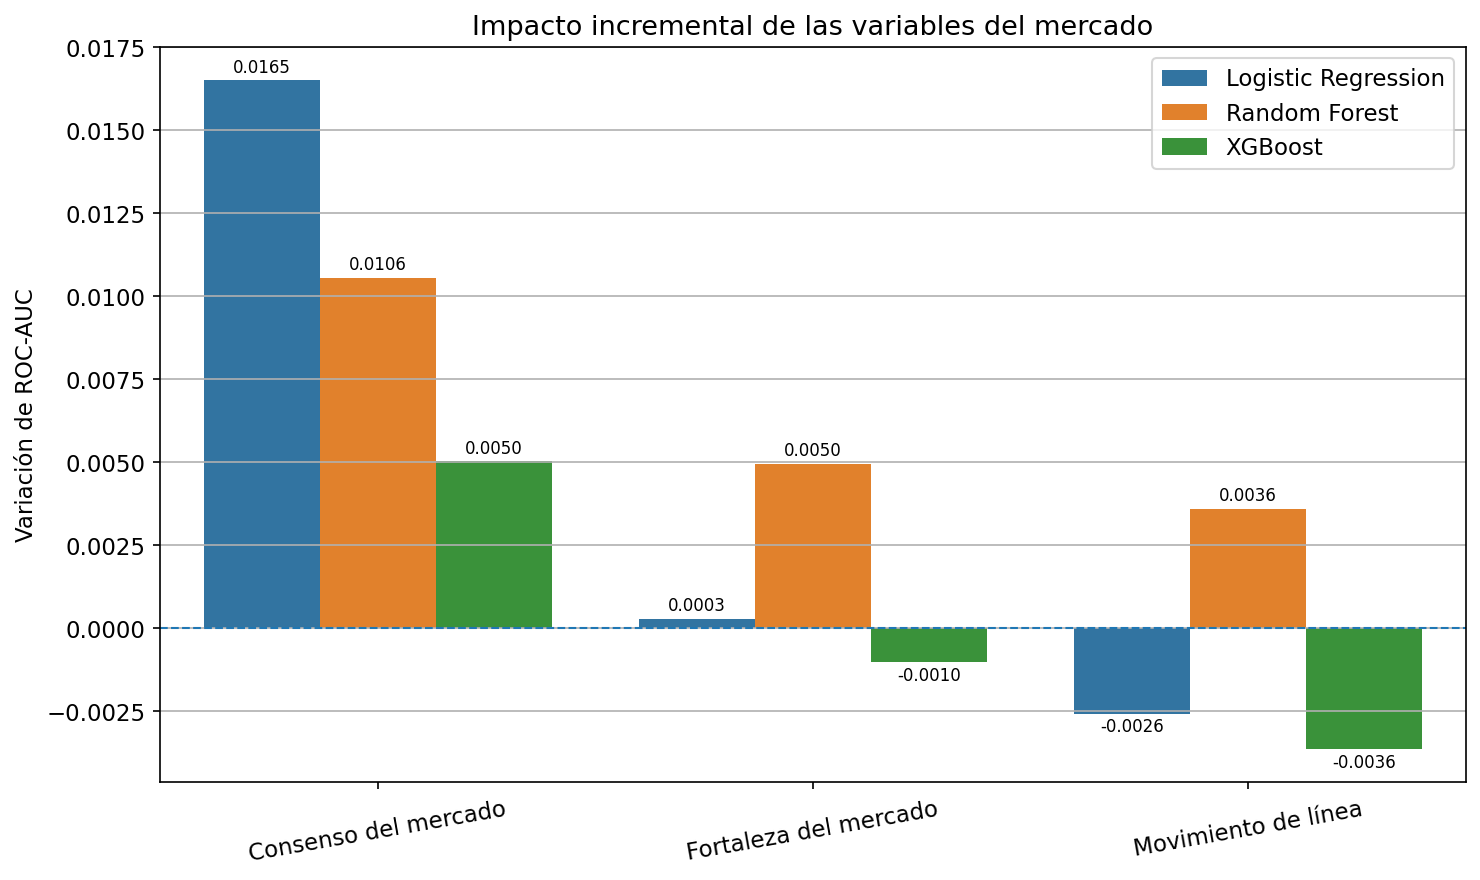

In [465]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=market_impact_long,
    x="Dimensión del mercado",
    y="Delta ROC-AUC",
    hue="Modelo"
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title("Impacto incremental de las variables del mercado")
plt.xlabel("")
plt.ylabel("Variación de ROC-AUC")
plt.xticks(rotation=10)
plt.legend(title="")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=2,
        fontsize=8
    )

save_fig("figura_4_17_impacto_incremental_variables_mercado")

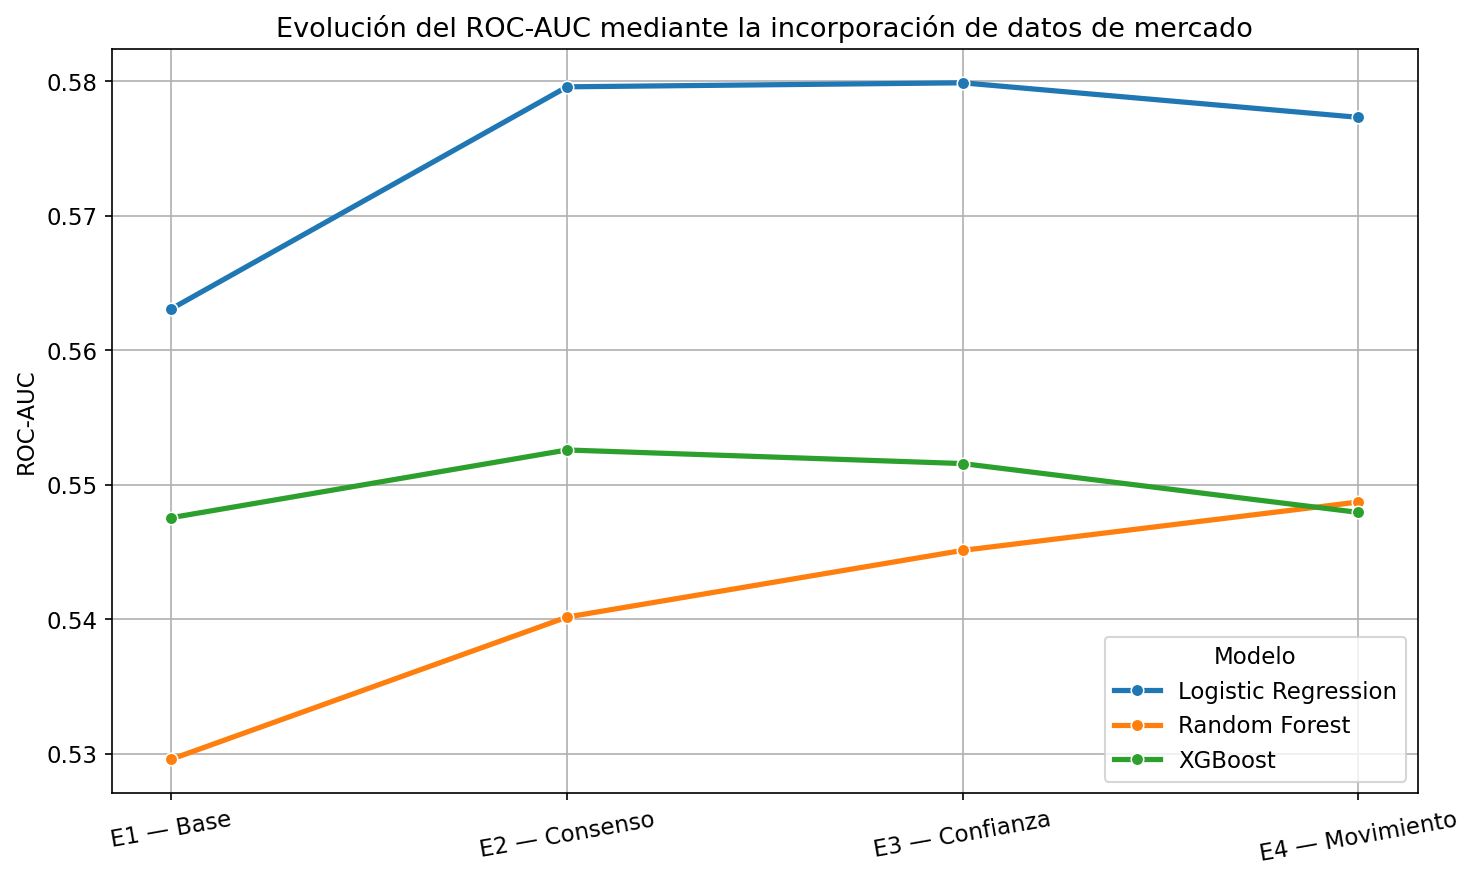

In [466]:
experiment_labels = {
    "E1_Base": "E1 — Base",
    "E2_Consensus": "E2 — Consenso",
    "E3_Confidence": "E3 — Confianza",
    "E4_Movement": "E4 — Movimiento"
}

progression_df = results_df.copy()

progression_df["Experimento"] = (
    progression_df["experiment"]
    .map(experiment_labels)
)

progression_df["Orden"] = (
    progression_df["experiment"]
    .map({
        "E1_Base": 1,
        "E2_Consensus": 2,
        "E3_Confidence": 3,
        "E4_Movement": 4
    })
)

progression_df = progression_df.sort_values(
    ["model_name", "Orden"]
)

plt.figure(figsize=(10, 6))

ax = sns.lineplot(
    data=progression_df,
    x="Experimento",
    y="roc_auc",
    hue="model_name",
    marker="o",
    linewidth=2.5
)

plt.title("Evolución del ROC-AUC mediante la incorporación de datos de mercado")
plt.xlabel("")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=10)
plt.legend(title="Modelo")

save_fig("figura_4_18_evolucion_roc_auc_experimentos")

## <font color='00FF00'>



## <font color='00FF00'> Optimización de hiperparámetros



In [467]:
# ============================================================
# 4.4.4 OPTIMIZACIÓN DE HIPERPARÁMETROS
# CONFIGURACIÓN FINAL DE VARIABLES
# ============================================================

final_numeric_features = (
    base_numeric_features
    + market_feature_groups["consensus"]
    + market_feature_groups["confidence"]
)

final_categorical_features = (
    base_categorical_features.copy()
)

print("Variables numéricas finales:")
print(final_numeric_features)

print("\nVariables categóricas finales:")
print(final_categorical_features)

print("\nNúmero de variables numéricas:", len(final_numeric_features))
print("Número de variables categóricas:", len(final_categorical_features))

Variables numéricas finales:
['seriesGameNumber', 'win_pct_diff', 'wins_diff', 'xwoba_diff', 'xba_diff', 'launch_speed_diff', 'iso_diff', 'home_close_prob_mean', 'close_market_strength']

Variables categóricas finales:
['dayNight', 'teams.home.team.name', 'teams.away.team.name']

Número de variables numéricas: 9
Número de variables categóricas: 3


In [468]:
# ============================================================
# IMPORTACIONES PARA OPTIMIZACIÓN
# ============================================================

from sklearn.model_selection import RandomizedSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)

In [469]:
# ============================================================
# FUNCIÓN GENERAL DE OPTIMIZACIÓN
# ============================================================

def tune_model(
    df,
    model_name,
    estimator,
    param_distributions,
    numeric_features,
    categorical_features,
    target,
    train_idx,
    test_idx,
    n_iter=30,
    cv=5,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
):
    """
    Optimiza un modelo mediante RandomizedSearchCV y evalúa
    el mejor estimador sobre el conjunto de prueba reservado.
    """

    selected_features = (
        numeric_features
        + categorical_features
    )

    X = df[selected_features].copy()
    y = df[target].copy()

    X_train = X.loc[train_idx]
    X_test = X.loc[test_idx]

    y_train = y.loc[train_idx]
    y_test = y.loc[test_idx]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                StandardScaler(),
                numeric_features
            ),
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                categorical_features
            )
        ]
    )

    pipeline = Pipeline([
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            clone(estimator)
        )
    ])

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring=scoring,
        cv=cv,
        random_state=random_state,
        n_jobs=n_jobs,
        verbose=1,
        refit=True,
        return_train_score=True
    )

    search.fit(
        X_train,
        y_train
    )

    best_pipeline = search.best_estimator_

    y_pred = best_pipeline.predict(X_test)

    y_prob = best_pipeline.predict_proba(
        X_test
    )[:, 1]

    metrics = {
        "model_name": model_name,
        "best_cv_roc_auc": search.best_score_,
        "test_accuracy": accuracy_score(
            y_test,
            y_pred
        ),
        "test_precision": precision_score(
            y_test,
            y_pred
        ),
        "test_recall": recall_score(
            y_test,
            y_pred
        ),
        "test_f1": f1_score(
            y_test,
            y_pred
        ),
        "test_roc_auc": roc_auc_score(
            y_test,
            y_prob
        )
    }

    return {
        "metrics": metrics,
        "best_params": search.best_params_,
        "best_pipeline": best_pipeline,
        "search": search,
        "y_test": y_test.copy(),
        "y_pred": y_pred,
        "y_prob": y_prob
    }

In [470]:
# ============================================================
# MODELOS PARA OPTIMIZACIÓN
# ============================================================

logreg_estimator = LogisticRegression(
    max_iter=2000,
    random_state=42
)

rf_estimator = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

xgb_estimator = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [471]:
# ============================================================
# ESPACIO DE BÚSQUEDA — REGRESIÓN LOGÍSTICA
# ============================================================

logreg_params = {
    "model__C": np.logspace(-3, 3, 30),
    "model__solver": [
        "liblinear",
        "saga"
    ],
    "model__penalty": [
        "l1",
        "l2"
    ],
    "model__class_weight": [
        None,
        "balanced"
    ]
}

In [472]:
# ============================================================
# ESPACIO DE BÚSQUEDA — RANDOM FOREST
# ============================================================

rf_params = {
    "model__n_estimators": [
        200,
        300,
        500,
        700,
        1000
    ],
    "model__max_depth": [
        None,
        5,
        10,
        15,
        20,
        30
    ],
    "model__min_samples_split": [
        2,
        5,
        10,
        20
    ],
    "model__min_samples_leaf": [
        1,
        2,
        4,
        8
    ],
    "model__max_features": [
        "sqrt",
        "log2",
        0.5,
        None
    ],
    "model__bootstrap": [
        True,
        False
    ]
}

In [473]:
# ============================================================
# ESPACIO DE BÚSQUEDA — XGBOOST
# ============================================================

xgb_params = {
    "model__n_estimators": [
        100,
        200,
        300,
        500,
        700
    ],
    "model__max_depth": [
        2,
        3,
        4,
        5,
        6,
        8
    ],
    "model__learning_rate": [
        0.01,
        0.03,
        0.05,
        0.08,
        0.1,
        0.2
    ],
    "model__subsample": [
        0.6,
        0.7,
        0.8,
        0.9,
        1.0
    ],
    "model__colsample_bytree": [
        0.6,
        0.7,
        0.8,
        0.9,
        1.0
    ],
    "model__min_child_weight": [
        1,
        3,
        5,
        7,
        10
    ],
    "model__gamma": [
        0,
        0.05,
        0.1,
        0.2,
        0.5
    ],
    "model__reg_alpha": [
        0,
        0.001,
        0.01,
        0.1,
        1
    ],
    "model__reg_lambda": [
        0.1,
        0.5,
        1,
        2,
        5,
        10
    ]
}

In [474]:
# ============================================================
# TUNING — REGRESIÓN LOGÍSTICA
# ============================================================

tuned_logreg = tune_model(
    df=df,
    model_name="Logistic Regression",
    estimator=logreg_estimator,
    param_distributions=logreg_params,
    numeric_features=final_numeric_features,
    categorical_features=final_categorical_features,
    target=target,
    train_idx=train_idx,
    test_idx=test_idx,
    n_iter=30,
    cv=5
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [475]:
# ============================================================
# TUNING — RANDOM FOREST
# ============================================================

tuned_rf = tune_model(
    df=df,
    model_name="Random Forest",
    estimator=rf_estimator,
    param_distributions=rf_params,
    numeric_features=final_numeric_features,
    categorical_features=final_categorical_features,
    target=target,
    train_idx=train_idx,
    test_idx=test_idx,
    n_iter=30,
    cv=5
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [476]:
# ============================================================
# TUNING — XGBOOST
# ============================================================

tuned_xgb = tune_model(
    df=df,
    model_name="XGBoost",
    estimator=xgb_estimator,
    param_distributions=xgb_params,
    numeric_features=final_numeric_features,
    categorical_features=final_categorical_features,
    target=target,
    train_idx=train_idx,
    test_idx=test_idx,
    n_iter=30,
    cv=5
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [477]:
# ============================================================
# RESULTADOS DE LOS MODELOS OPTIMIZADOS
# ============================================================

tuned_results = {
    "Logistic Regression": tuned_logreg,
    "Random Forest": tuned_rf,
    "XGBoost": tuned_xgb
}

tuned_results_df = pd.DataFrame(
    [
        result["metrics"]
        for result in tuned_results.values()
    ]
)

tuned_results_df = (
    tuned_results_df
    .sort_values(
        by="test_roc_auc",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    tuned_results_df.round(4)
)

,model_name,best_cv_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,Logistic Regression,0.5952,0.5795,0.6041,0.5771,0.5903,0.6090
1,XGBoost,0.5872,0.5710,0.5820,0.6487,0.6136,0.5903
2,Random Forest,0.5874,0.5428,0.5786,0.4749,0.5217,0.5815


In [478]:
tuned_results_df.to_csv(
    output_path / "tabla_4_27_resultados_modelos_optimizados.csv",
    index=False,
    encoding="utf-8-sig"
)

In [479]:
tuned_results_clean = (
    tuned_results_df
    .rename(columns={
        "model_name": "Modelo",
        "best_cv_roc_auc": "ROC-AUC CV",
        "test_accuracy": "Accuracy",
        "test_precision": "Precision",
        "test_recall": "Recall",
        "test_f1": "F1",
        "test_roc_auc": "ROC-AUC Test"
    })
)

display(
    tuned_results_clean.round(4)
)

,Modelo,ROC-AUC CV,Accuracy,Precision,Recall,F1,ROC-AUC Test
0,Logistic Regression,0.5952,0.5795,0.6041,0.5771,0.5903,0.6090
1,XGBoost,0.5872,0.5710,0.5820,0.6487,0.6136,0.5903
2,Random Forest,0.5874,0.5428,0.5786,0.4749,0.5217,0.5815


In [480]:
tuned_results_clean.to_csv(
    output_path / "tabla_4_28_resultados_optimizados_limpios.csv",
    index=False,
    encoding="utf-8-sig"
)

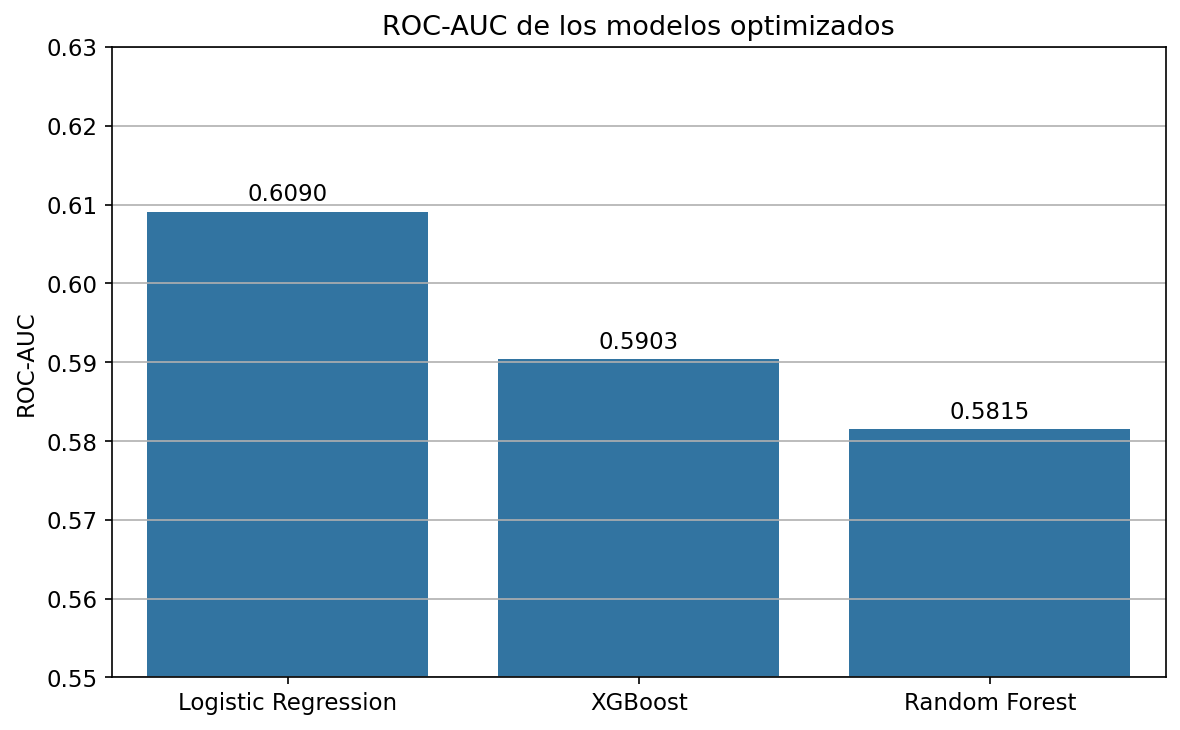

In [481]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=tuned_results_df,
    x="model_name",
    y="test_roc_auc"
)

plt.title("ROC-AUC de los modelos optimizados")
plt.xlabel("")
plt.ylabel("ROC-AUC")
plt.ylim(
    0.55,
    max(
        0.63,
        tuned_results_df["test_roc_auc"].max() + 0.02
    )
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=3
    )

save_fig("figura_4_19_roc_auc_modelos_optimizados")

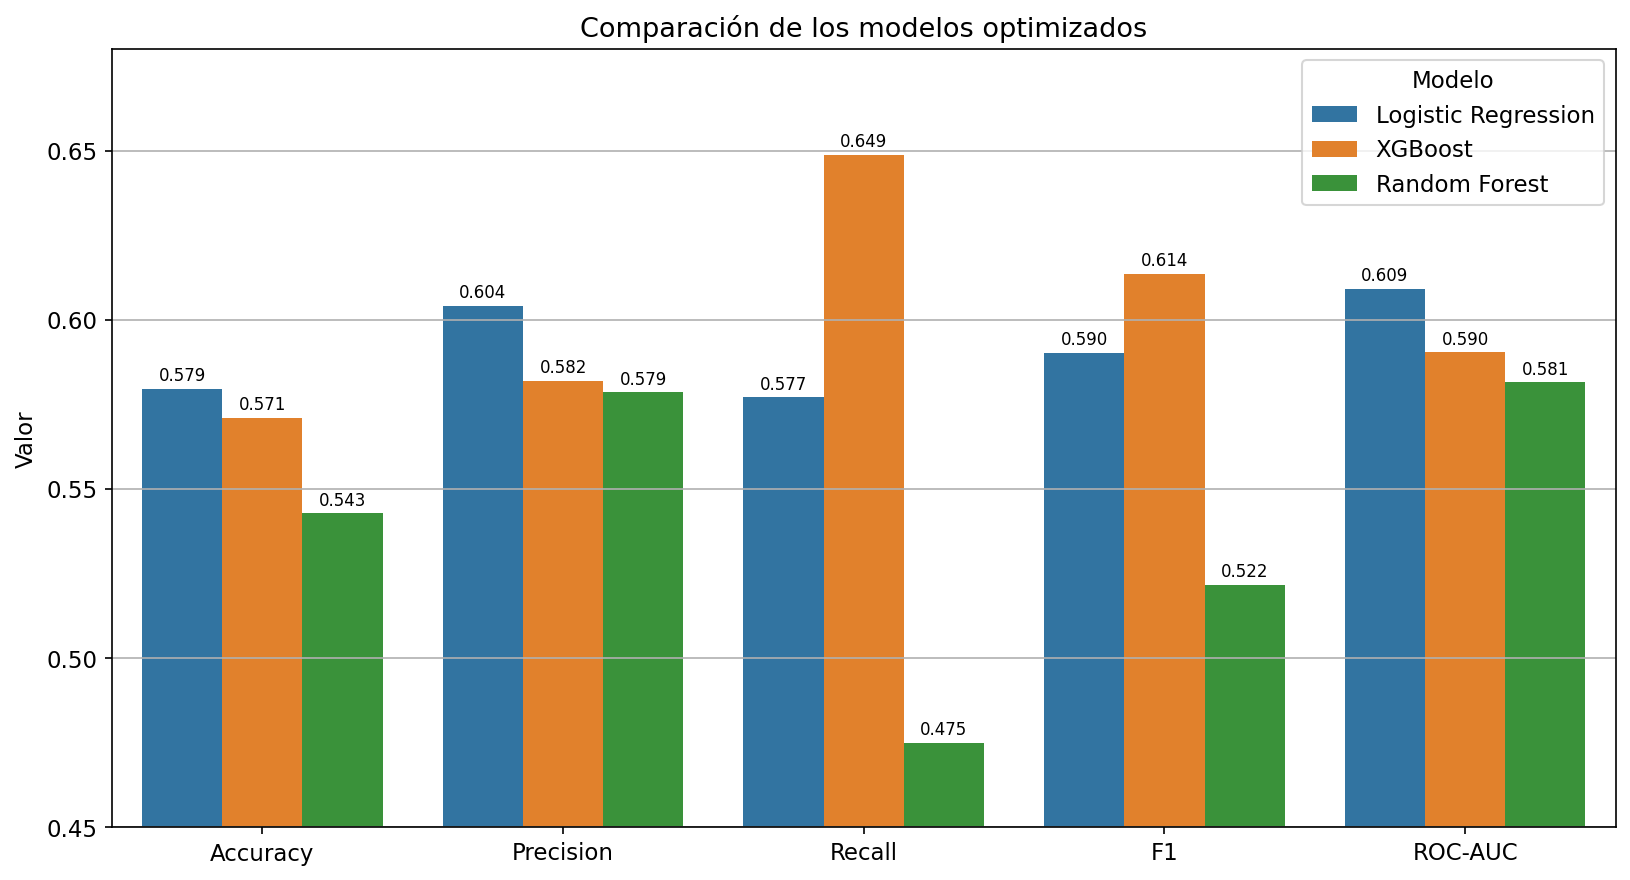

In [482]:
tuned_metrics_long = (
    tuned_results_df[
        [
            "model_name",
            "test_accuracy",
            "test_precision",
            "test_recall",
            "test_f1",
            "test_roc_auc"
        ]
    ]
    .melt(
        id_vars="model_name",
        var_name="Métrica",
        value_name="Valor"
    )
)

tuned_metrics_long["Métrica"] = (
    tuned_metrics_long["Métrica"]
    .replace({
        "test_accuracy": "Accuracy",
        "test_precision": "Precision",
        "test_recall": "Recall",
        "test_f1": "F1",
        "test_roc_auc": "ROC-AUC"
    })
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=tuned_metrics_long,
    x="Métrica",
    y="Valor",
    hue="model_name"
)

plt.title("Comparación de los modelos optimizados")
plt.xlabel("")
plt.ylabel("Valor")
plt.ylim(0.45, 0.68)
plt.legend(title="Modelo")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=2,
        fontsize=8
    )

save_fig("figura_4_20_metricas_modelos_optimizados")

In [483]:
# ============================================================
# TABLA DE MEJORES HIPERPARÁMETROS
# ============================================================

best_params_rows = []

for model_name, result in tuned_results.items():

    for parameter, value in result["best_params"].items():

        best_params_rows.append({
            "Modelo": model_name,
            "Hiperparámetro": (
                parameter
                .replace("model__", "")
            ),
            "Valor": value
        })

best_params_df = pd.DataFrame(
    best_params_rows
)

display(best_params_df)

,Modelo,Hiperparámetro,Valor
0,Logistic Regression,solver,liblinear
1,Logistic Regression,penalty,l1
2,Logistic Regression,class_weight,None
3,Logistic Regression,C,0.004175
4,Random Forest,n_estimators,300
5,Random Forest,min_samples_split,5
6,Random Forest,min_samples_leaf,8
7,Random Forest,max_features,log2
8,Random Forest,max_depth,5
9,Random Forest,bootstrap,True


In [484]:
best_params_df.to_csv(
    output_path / "tabla_4_29_mejores_hiperparametros.csv",
    index=False,
    encoding="utf-8-sig"
)

In [485]:
# ============================================================
# COMPARACIÓN ANTES Y DESPUÉS DE LA OPTIMIZACIÓN
# ============================================================

model_name_map = {
    "Logistic Regression": "Logistic Regression",
    "Random Forest": "Random Forest",
    "XGBoost": "XGBoost"
}

base_e3_results = (
    results_df[
        results_df["experiment"] == "E3_Confidence"
    ][
        [
            "model_name",
            "accuracy",
            "roc_auc"
        ]
    ]
    .copy()
)

before_after = base_e3_results.merge(
    tuned_results_df[
        [
            "model_name",
            "test_accuracy",
            "test_roc_auc"
        ]
    ],
    on="model_name",
    how="inner"
)

before_after["Delta Accuracy"] = (
    before_after["test_accuracy"]
    - before_after["accuracy"]
)

before_after["Delta ROC-AUC"] = (
    before_after["test_roc_auc"]
    - before_after["roc_auc"]
)

before_after = before_after.rename(columns={
    "model_name": "Modelo",
    "accuracy": "Accuracy antes",
    "roc_auc": "ROC-AUC antes",
    "test_accuracy": "Accuracy optimizada",
    "test_roc_auc": "ROC-AUC optimizado"
})

display(
    before_after.round(4)
)

,Modelo,Accuracy antes,ROC-AUC antes,Accuracy optimizada,ROC-AUC optimizado,Delta Accuracy,Delta ROC-AUC
0,Logistic Regression,0.5691,0.5799,0.5795,0.6090,0.0103,0.0292
1,Random Forest,0.5400,0.5451,0.5428,0.5815,0.0028,0.0364
2,XGBoost,0.5428,0.5516,0.5710,0.5903,0.0282,0.0388


In [486]:
before_after.to_csv(
    output_path / "tabla_4_30_antes_despues_optimizacion.csv",
    index=False,
    encoding="utf-8-sig"
)

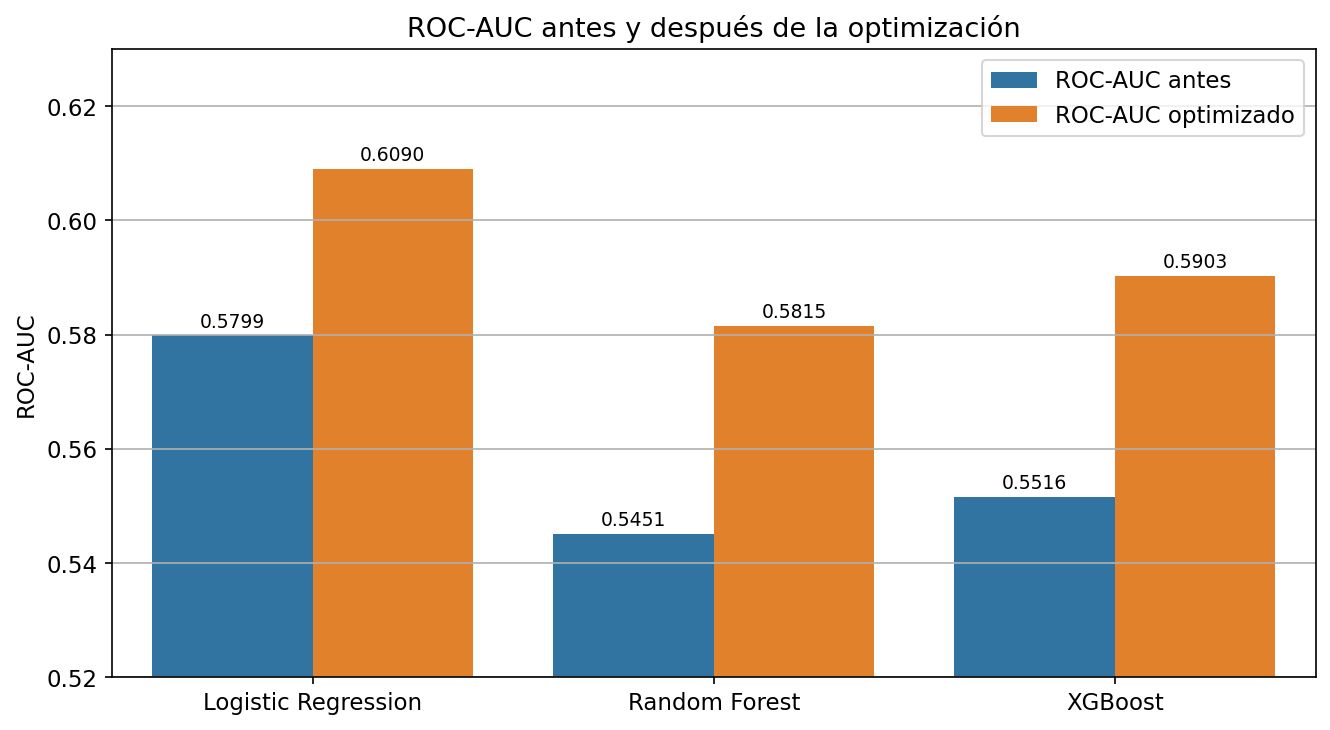

In [487]:
before_after_long = before_after.melt(
    id_vars="Modelo",
    value_vars=[
        "ROC-AUC antes",
        "ROC-AUC optimizado"
    ],
    var_name="Configuración",
    value_name="ROC-AUC"
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=before_after_long,
    x="Modelo",
    y="ROC-AUC",
    hue="Configuración"
)

plt.title("ROC-AUC antes y después de la optimización")
plt.xlabel("")
plt.ylabel("ROC-AUC")
plt.ylim(0.52, 0.63)
plt.legend(title="")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=2,
        fontsize=9
    )

save_fig("figura_4_21_antes_despues_optimizacion")